In [ ]:
"""
=============================================================================
案例教程 22: 连续血糖监测 (CGM) 餐后血糖反应回归流水线 — 回归任务迁移
=============================================================================
教学目标: 在 CGM 餐级数据上跑通【完整的回归 ML 流程】, 并在每一步显式对照
         前面教程 01-12 的分类知识点, 让学生看清"从分类迁移到回归, 哪些步骤
         完全相同, 哪些步骤因连续目标 / 分组结构而不同".

本脚本 = 一个综合案例, 覆盖机器学习的全部步骤:
  ① EDA           → 对照教程 01  (连续目标分布 / log1p / 每受试者餐次)
  ② 统计分析      → 对照教程 02  (Pearson/Spearman 相关 + FDR, 替代组间检验)
  ③ 预处理        → 对照教程 03/04 (中位数插补 + OneHot + 标准化, 防泄漏)
  ④ 特征选择/消融 → 对照教程 05  (M0→M4 消融 + LASSO 稀疏 signature)
  ⑤ 防泄漏+划分   → 对照教程 07  (★4 种划分策略 + 泄漏审计, 本案例核心)
  ⑥ 交叉验证      → 对照教程 08  (朴素 KFold 泄漏 vs GroupKFold 真实泛化)
  ⑦ 建模对比      → 对照教程 09  (11 个 Regressor)
  ⑧ 目标变换/残差 → 对照教程 10  (回归无不平衡 → winsorize + log1p + 残差思维)
  ⑨ 回归校准+诊断 → 对照教程 11  (观测vs预测 + 残差QQ/同方差, 替代校准/DCA)
  ⑩ SHAP 可解释   → 对照教程 12  (SHAP 值 = 目标单位 mg/dL·min)

任务: 用餐次营养 + 餐前 CGM + 可穿戴 + 临床 + 肠道特征预测 2h 增量血糖曲线下面积
      (iauc_2h, mg/dL·min). 1682 餐 × 45 受试者, 连续目标, 分组 + 时间结构.

★ 本案例两个核心教学点:
  1. 不同的数据划分策略 —— 4 种策略回答 4 个不同问题:
       朴素 KFold (反面教材, 泄漏) / GroupKFold (新用户) / 受试者内时间 (未来餐) / few-shot (冷启动)
  2. 回归任务的建模与评价 —— Regressor 替代 Classifier, MAE/RMSE/R²/Pearson 替代
       AUC/Recall, 残差诊断替代校准/DCA, subject-level bootstrap CI 量化不确定性.

=============================================================================
"""

In [2]:

import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import (KFold, GroupKFold, RepeatedKFold,
                                     cross_val_score)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                  LassoCV)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor,
                              HistGradientBoostingRegressor)
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)

import xgboost as xgb
import lightgbm as lgb
import shap

warnings.filterwarnings('ignore')
import logging as _logging
_logging.getLogger('shap').setLevel(_logging.ERROR)   # 抑制 shap 冗余日志

In [3]:
BASE_DIR = ".."
DATA_CSV = os.path.join(BASE_DIR, "data", "cgm_data", "meal_level_dataset.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

RANDOM_STATE = 42
N_JOBS = -1
N_BOOTSTRAP = 500        # subject-level bootstrap 次数 (论文级用 1000, 教程提速用 500)
SHAP_SAMPLE = 600        # beeswarm 子样本量 (1682 全量渲染慢)
PRIMARY_TARGET = "iauc_2h"      # 2h 增量血糖曲线下面积 (主目标)
CO_TARGET = "peak_delta_2h"     # 2h 峰值血糖升幅 (协同目标)
np.random.seed(RANDOM_STATE)


In [4]:
MEAL_FEATURES = ["eff_calories", "eff_carbs", "eff_protein", "eff_fat", "eff_fiber"]
PRE_CGM_FEATURES = ["baseline_glucose", "pre_glucose_mean_30",
                    "pre_glucose_sd_30", "pre_glucose_slope_60"]
WEARABLE_TIME_FEATURES = ["hr_mean_pre30", "activity_calories_pre30", "mets_mean_pre30",
                          "meal_hour_sin", "meal_hour_cos", "prev_meal_gap_min"]
CLINICAL_FEATURES = ["Age", "BMI", "Body weight", "Height", "A1c PDL (Lab)",
                     "Fasting GLU - PDL (Lab)", "Insulin", "Triglycerides",
                     "Cholesterol", "HDL", "Non HDL", "LDL (Cal)", "VLDL (Cal)",
                     "Cho/HDL Ratio"]
BASE_CATEGORICAL = ["meal_type"]
CLINICAL_CATEGORICAL = ["Gender"]

In [5]:
# ---- 禁止进入模型的变量 (泄漏审计) ----
FORBIDDEN_EXACT = {
    "calories", "carbs", "protein", "fat", "fiber",          # 原始营养, 被 eff_* 替代
    "amount_consumed", "amount_factor",
    "auc_2h", "iauc_2h", "peak_glucose_2h", "peak_delta_2h",  # 结果变量 (目标!)
    "time_to_peak_2h", "recovery_time_2h", "auc_3h", "iauc_3h",
    "image_path", "glucose_source", "n_pre_points", "n_post2h_points",
    "Time (t)", "Time (t).1", "Time (t).2", "Collection time PDL (Lab)",
    "#1 Contour Fingerstick GLU", "#2 Contour Fingerstick GLU", "#3 Contour Fingerstick GLU",
    "Self-identify",                                           # 族裔, 主模型禁用 (同参考)
}
FORBIDDEN_REGEX = [r"fingerstick", r"contour", r"image", r"glucose_source",
                   r"^auc_", r"^iauc_", r"^peak_", r"recovery", r"time_to_peak",
                   r"n_pre_points", r"n_post2h_points", r"collection time", r"^time \(t\)"]

In [6]:

 




# ============================================================================
# 工具函数
# ============================================================================
def forbidden_reason(col):
    """判断列是否禁止进入模型. 返回 None=允许, 字符串=禁止原因."""
    c = str(col).strip()
    lower = c.lower()
    if c in FORBIDDEN_EXACT:
        return "explicitly_forbidden"
    for pat in FORBIDDEN_REGEX:
        if re.search(pat, lower):
            return f"regex_forbidden:{pat}"
    if lower in ["calories", "carbs", "protein", "fat", "fiber", "amount consumed"]:
        return "raw_nutrient_duplicate"
    return None


def build_leakage_audit(df):
    rows = []
    for col in df.columns:
        reason = forbidden_reason(col)
        if reason is not None:
            rows.append({"column": col, "reason": reason,
                         "dtype": str(df[col].dtype),
                         "missing_rate": float(df[col].isna().mean())})
    return pd.DataFrame(rows).sort_values(["reason", "column"]).reset_index(drop=True)


def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def pearson_r(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    if len(y_true) < 2 or np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan
    return float(np.corrcoef(y_true, y_pred)[0, 1])


def safe_mape(y_true, y_pred):
    """MAPE 对接近 0 的目标不稳定 (iauc_2h 有 0 值) → 只在 |y_true|>1 上计算并报告覆盖度."""
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mask = np.abs(y_true) > 1.0
    if mask.sum() < 10:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])))


def evaluate_predictions(y_true, y_pred):
    """回归评估全家桶 —— 对照教程 09 的 AUC/Recall/Brier."""
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
        "Pearson_r": pearson_r(y_true, y_pred),
        "MAPE": safe_mape(y_true, y_pred),
        "n_test": int(len(y_true)),
    }


def make_pipeline(model, numeric_features, categorical_features):
    """防泄漏 Pipeline —— 对照教程 07. 数值: 中位数插补+标准化; 分类: 众数插补+OneHot.
    每个 fold 内重新 fit (imputer/scaler 只见本 fold 训练数据)."""
    transformers = []
    if numeric_features:
        transformers.append(("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())]), numeric_features))
    if categorical_features:
        transformers.append(("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_onehot_encoder())]), categorical_features))
    if not transformers:
        raise RuntimeError("No valid features available.")
    pre = ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=0.0)
    return Pipeline(steps=[("preprocess", pre), ("model", clone(model))])


def get_models():
    """11 个 Regressor —— 对照教程 09 的 11 个 Classifier, 同算法族换 predict/loss."""
    return {
        "LinearRegression": LinearRegression(),
        "Ridge":            Ridge(alpha=1.0, random_state=RANDOM_STATE),
        "Lasso":            Lasso(alpha=0.1, max_iter=10000, random_state=RANDOM_STATE),
        "ElasticNet":       ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000,
                                       random_state=RANDOM_STATE),
        "KNN":              KNeighborsRegressor(n_neighbors=15, n_jobs=N_JOBS),
        "SVR":              SVR(C=1.0, kernel="rbf"),
        "DecisionTree":     DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
        "RandomForest":     RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                                  random_state=RANDOM_STATE, n_jobs=N_JOBS),
        "HGB":              HistGradientBoostingRegressor(max_iter=400, learning_rate=0.03,
                                                          max_leaf_nodes=31, random_state=RANDOM_STATE),
        "XGBoost":          xgb.XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                                             random_state=RANDOM_STATE, n_jobs=N_JOBS, verbosity=0),
        "LightGBM":         lgb.LGBMRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                                              random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=-1),
    }


def normalize_meal_type(df):
    """meal_type 原始有大小写不一致 (Lunch/lunch, Snacks/snack) → 归一化."""
    s = df["meal_type"].astype(str).str.strip().str.lower()
    s = s.replace({"snack": "snacks"})
    df = df.copy()
    df["meal_type"] = s
    return df


def identify_gut_features(df):
    """从列名识别 22 项肠道健康评分 (gut_health_test 合并进来的列)."""
    gut_keywords = ("Pathways", "Health", "Production", "Activity", "Efficiency",
                    "Fermentation", "Gas", "Stress", "Diversity", "Metabolism", "Fitness",
                    "Lining", "Biofilm", "TMA", "Ammonia", "Butyrate", "Flagellar",
                    "Putrescine", "Uric", "Bile", "Inflammatory", "Digestive",
                    "Microbiome", "Oxalate", "Salt")
    return [c for c in df.columns
            if c not in ("subject_id",) and any(k.lower() in c.lower() for k in gut_keywords)
            and forbidden_reason(c) is None]


def build_feature_sets(df):
    """M0→M4 消融阶梯 (改编自参考 build_feature_sets)."""
    # gut 识别可能误抓 wearable/clinical 列 (如 activity_calories_pre30 含 "activity")
    # → 排除已属于 M3 数值特征组的列, 只保留真正的肠道评分
    m3_numeric = set(MEAL_FEATURES + PRE_CGM_FEATURES + WEARABLE_TIME_FEATURES + CLINICAL_FEATURES)
    gut = [c for c in identify_gut_features(df) if c not in m3_numeric]
    existing = set(df.columns)
    def ok(cols):
        """保留 df 中存在且去重 (保序) 的列 — 防止 ColumnTransformer 重复列报错."""
        seen = set(); out = []
        for c in cols:
            if c in existing and c not in seen:
                seen.add(c); out.append(c)
        return out

    sets = {}
    sets["M0_meal_only"] = {
        "numeric": ok(MEAL_FEATURES),
        "categorical": ok(BASE_CATEGORICAL),
        "description": "仅餐次营养 (基线)"}
    sets["M1_meal_pre_cgm"] = {
        "numeric": ok(MEAL_FEATURES + PRE_CGM_FEATURES),
        "categorical": ok(BASE_CATEGORICAL),
        "description": "M0 + 餐前 CGM 状态"}
    sets["M2_wearable_time"] = {
        "numeric": ok(MEAL_FEATURES + PRE_CGM_FEATURES + WEARABLE_TIME_FEATURES),
        "categorical": ok(BASE_CATEGORICAL),
        "description": "M1 + 可穿戴 + 时间 (可部署核心)"}
    sets["M3_clinical"] = {
        "numeric": ok(MEAL_FEATURES + PRE_CGM_FEATURES + WEARABLE_TIME_FEATURES + CLINICAL_FEATURES),
        "categorical": ok(BASE_CATEGORICAL + CLINICAL_CATEGORICAL),
        "description": "M2 + 临床基线 (主模型)"}
    sets["M4_gut"] = {
        "numeric": ok(MEAL_FEATURES + PRE_CGM_FEATURES + WEARABLE_TIME_FEATURES + CLINICAL_FEATURES + gut),
        "categorical": ok(BASE_CATEGORICAL + CLINICAL_CATEGORICAL),
        "description": "M3 + 肠道健康 (探索)"}
    return sets


def bh_fdr(pvals):
    """Benjamini-Hochberg FDR 校正 —— 与教程 20/21 一致的实现."""
    p = np.asarray(pvals, float)
    order = np.argsort(p)
    ranked = p[order]
    m = len(p)
    q = ranked * m / (np.arange(m) + 1)
    fdr = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty_like(fdr)
    out[order] = fdr
    return np.clip(out, 0, 1)


# ============================================================================
# 4 种划分策略 (本案例核心) —— 返回带 subject_id 的预测 DataFrame
# ============================================================================
def split_naive_kfold_oof(df, target, spec, model, n_splits=5):
    """① 朴素随机 KFold —— 反面教材! 同一受试者餐次可能同时进 train+test → 泄漏."""
    features = spec["numeric"] + spec["categorical"]
    X, y = df[features], df[target].values
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    for tr, te in kf.split(X):
        pipe = make_pipeline(model, spec["numeric"], spec["categorical"])
        pipe.fit(X.iloc[tr], y[tr])
        pred = pipe.predict(X.iloc[te])
        for i, j in enumerate(te):
            rows.append({"subject_id": df.iloc[j]["subject_id"],
                         "y_true": y[j], "y_pred": pred[i]})
    return pd.DataFrame(rows)


def split_groupkfold_oof(df, target, spec, model, n_splits=5):
    """② GroupKFold by subject_id —— 回答"能泛化到新用户吗"(部署问题). 训练/测试受试者不交叉."""
    features = spec["numeric"] + spec["categorical"]
    X, y = df[features], df[target].values
    groups = df["subject_id"].values
    gkf = GroupKFold(n_splits=min(n_splits, df["subject_id"].nunique()))
    rows = []
    for tr, te in gkf.split(X, y, groups):
        pipe = make_pipeline(model, spec["numeric"], spec["categorical"])
        pipe.fit(X.iloc[tr], y[tr])
        pred = pipe.predict(X.iloc[te])
        for i, j in enumerate(te):
            rows.append({"subject_id": df.iloc[j]["subject_id"],
                         "y_true": y[j], "y_pred": pred[i]})
    return pd.DataFrame(rows)


def split_temporal_holdout(df, target, spec, model):
    """③ 受试者内时间 80/20 —— 按 meal_time 排序, 每人前 80% 训练/后 20% 测试.
    回答"能预测某用户未来餐次吗"(老用户问题). 返回 (pred_df_test, train_idx, test_idx)."""
    data = df.sort_values(["subject_id", "meal_time"]).reset_index(drop=True)
    train_idx, test_idx = [], []
    for sid, sub in data.groupby("subject_id"):
        idx = sub.index.to_numpy()
        n = len(idx)
        if n < 5:
            train_idx.extend(idx.tolist()); continue
        cut = max(1, min(int(np.floor(n * 0.8)), n - 1))
        train_idx.extend(idx[:cut].tolist())
        test_idx.extend(idx[cut:].tolist())
    features = spec["numeric"] + spec["categorical"]
    X, y = data[features], data[target].values
    tr, te = np.array(train_idx), np.array(test_idx)
    pipe = make_pipeline(model, spec["numeric"], spec["categorical"])
    pipe.fit(X.iloc[tr], y[tr])
    pred = pipe.predict(X.iloc[te])
    pred_df = pd.DataFrame({"subject_id": data.iloc[te]["subject_id"].values,
                            "y_true": y[te], "y_pred": pred})
    return pred_df, data, tr, te


def split_fewshot(df, target, spec, model, shots_list=(0, 1, 3, 5, 10)):
    """④ Few-shot 个性化 —— 训练=其他全部受试者 + 本人前 k 餐, 测试=本人剩余.
    回答"新用户需登录多少餐预测才有用"(冷启动问题)."""
    data = df.sort_values(["subject_id", "meal_time"]).reset_index(drop=True)
    features = spec["numeric"] + spec["categorical"]
    out = {}
    for k in shots_list:
        rows = []
        for sid, sub in data.groupby("subject_id"):
            sub = sub.sort_values("meal_time")
            if len(sub) <= k + 3:
                continue
            adapt, test = sub.iloc[:k], sub.iloc[k:]
            train_base = data[data["subject_id"] != sid]
            train = pd.concat([train_base, adapt], axis=0, ignore_index=True) if k > 0 else train_base
            pipe = make_pipeline(model, spec["numeric"], spec["categorical"])
            pipe.fit(train[features], train[target].values)
            pred = pipe.predict(test[features])
            for i in range(len(test)):
                rows.append({"subject_id": sid, "y_true": test[target].values[i],
                             "y_pred": pred[i]})
        out[k] = pd.DataFrame(rows)
    return out


def bootstrap_ci(pred_df, n_bootstrap=N_BOOTSTRAP, seed=RANDOM_STATE):
    """subject-level bootstrap: 重抽样受试者 (而非餐次) → 重算指标 → 95% CI.
    这是分组数据正确的不确定性量化方式 (重抽样餐次会低估方差)."""
    rng = np.random.RandomState(seed)
    subjects = np.unique(pred_df["subject_id"].values)
    base = evaluate_predictions(pred_df["y_true"].values, pred_df["y_pred"].values)
    samples = {"MAE": [], "RMSE": [], "R2": [], "Pearson_r": []}
    for _ in range(n_bootstrap):
        resampled = rng.choice(subjects, size=len(subjects), replace=True)
        mask = pred_df["subject_id"].isin(resampled).values
        if mask.sum() < 5:
            continue
        m = evaluate_predictions(pred_df["y_true"].values[mask],
                                 pred_df["y_pred"].values[mask])
        for k in samples:
            samples[k].append(m[k])
    ci = {}
    for k, vals in samples.items():
        vals = np.array(vals)
        ci[k] = (float(np.nanpercentile(vals, 2.5)), float(np.nanpercentile(vals, 97.5)))
    return base, ci


def fit_linear_calibrator(y_true, y_pred):
    """回归校准: 观测 = intercept + slope × 预测. 理想 slope=1, intercept=0."""
    slope, intercept = np.polyfit(y_pred, y_true, 1)
    return float(slope), float(intercept)




In [7]:
print("\n[0] 加载 CGM 餐级建模表 ...")
df = pd.read_csv(DATA_CSV)
df["meal_time"] = pd.to_datetime(df["meal_time"], errors="coerce")
df = df.dropna(subset=[PRIMARY_TARGET, "subject_id", "meal_time"]).reset_index(drop=True)


[0] 加载 CGM 餐级建模表 ...


In [8]:
# 目标 winsorize 1-99% (减少极端值影响, 与参考 clean_dataset 一致)
q_lo, q_hi = df[PRIMARY_TARGET].quantile([0.01, 0.99])
df = df[(df[PRIMARY_TARGET] >= q_lo) & (df[PRIMARY_TARGET] <= q_hi)].reset_index(drop=True)
df["subject_id"] = df["subject_id"].astype(int)
df = normalize_meal_type(df)

print(f"    样本数(餐次): {len(df)}  |  受试者数: {df['subject_id'].nunique()}")
print(f"    目标: {PRIMARY_TARGET} (2h 增量血糖曲线下面积, mg/dL·min)")
print(f"    winsorize 1-99%: [{q_lo:.0f}, {q_hi:.0f}]  (剔除极端值, 保留 {len(df)} 餐)")
print(f"    每受试者餐次: 中位数 {int(df.groupby('subject_id').size().median())}, "
      f"范围 [{df.groupby('subject_id').size().min()}, {df.groupby('subject_id').size().max()}]")


    样本数(餐次): 1665  |  受试者数: 45
    目标: iauc_2h (2h 增量血糖曲线下面积, mg/dL·min)
    winsorize 1-99%: [0, 14341]  (剔除极端值, 保留 1665 餐)
    每受试者餐次: 中位数 38, 范围 [17, 63]


In [9]:
# 构建特征集 + 保存 manifest
feature_sets = build_feature_sets(df)
manifest_rows = []
for name, spec in feature_sets.items():
    manifest_rows.append({"feature_set": name, "description": spec["description"],
                          "n_numeric": len(spec["numeric"]),
                          "n_categorical": len(spec["categorical"]),
                          "n_total": len(spec["numeric"]) + len(spec["categorical"]),
                          "numeric_features": ", ".join(spec["numeric"]),
                          "categorical_features": ", ".join(spec["categorical"])})
pd.DataFrame(manifest_rows).to_csv(os.path.join(RESULTS_DIR, "22_feature_manifest.csv"),
                                   index=False)
print(f"    特征集: {list(feature_sets.keys())}  (M3 为主模型, 共 "
      f"{len(feature_sets['M3_clinical']['numeric'])+len(feature_sets['M3_clinical']['categorical'])} 特征)")
print(f"  📄 22_feature_manifest.csv → M0-M4 特征清单已保存")

M3 = feature_sets["M3_clinical"]

    特征集: ['M0_meal_only', 'M1_meal_pre_cgm', 'M2_wearable_time', 'M3_clinical', 'M4_gut']  (M3 为主模型, 共 31 特征)
  📄 22_feature_manifest.csv → M0-M4 特征清单已保存



① EDA 探索性数据分析  (对照教程 01)

  ▶ 目标 iauc_2h 分布: 均值=2848  中位数=2123  偏度=1.26 (右偏 → 考虑 log1p 变换, 见 ⑧)
     log1p 变换后偏度=-1.85 (右偏缓解, 但 peak_delta_2h 有负值不能 log)
  ▶ 每受试者餐次数: 17-63, 中位数 38 → 分组结构明显 (同受试者餐次相关!)
  ▶ 缺失值 Top: {'recovery_time_2h': np.float64(0.52), 'mets_mean_pre30': np.float64(0.225), 'Gut Microbiome Health': np.float64(0.06), 'Ammonia Production Pathways': np.float64(0.06), 'Active Microbial Diversity': np.float64(0.06), 'Butyrate Production Pathways': np.float64(0.06), 'Flagellar Assembly Pathways': np.float64(0.06), 'Putrescine Production Pathways': np.float64(0.06), 'Uric Acid Production Pathways': np.float64(0.06), 'Bile Acid Metabolism Pathways': np.float64(0.06)}
     → mets_mean_pre30 缺失最多 (可穿戴设备未佩戴), 用中位数插补 (教程 03, 见 ③)
  [图] 22_eda_overview.png → 目标分布+餐次数+缺失率已保存


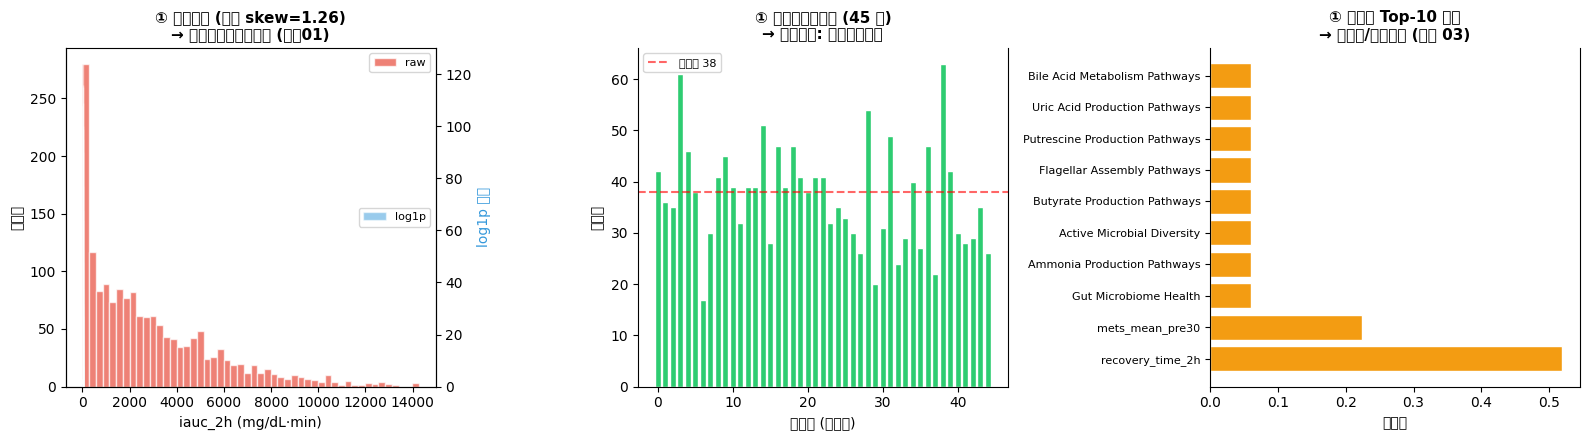

In [10]:
# ============================================================================
# ① EDA — 对照教程 01
# ============================================================================
print("\n" + "=" * 70)
print("① EDA 探索性数据分析  (对照教程 01)")
print("=" * 70)

y_raw = df[PRIMARY_TARGET].values
y_log = np.log1p(y_raw)
skew_raw = stats.skew(y_raw)
skew_log = stats.skew(y_log)
meals_per_subj = df.groupby("subject_id").size()
missing_top = df.isna().mean().sort_values(ascending=False)
missing_top = missing_top[missing_top > 0].head(10)

print(f"\n  ▶ 目标 {PRIMARY_TARGET} 分布: 均值={y_raw.mean():.0f}  中位数={np.median(y_raw):.0f}  "
      f"偏度={skew_raw:.2f} (右偏 → 考虑 log1p 变换, 见 ⑧)")
print(f"     log1p 变换后偏度={skew_log:.2f} (右偏缓解, 但 peak_delta_2h 有负值不能 log)")
print(f"  ▶ 每受试者餐次数: {meals_per_subj.min()}-{meals_per_subj.max()}, "
      f"中位数 {int(meals_per_subj.median())} → 分组结构明显 (同受试者餐次相关!)")
print(f"  ▶ 缺失值 Top: {dict(missing_top.round(3))}")
print(f"     → mets_mean_pre30 缺失最多 (可穿戴设备未佩戴), 用中位数插补 (教程 03, 见 ③)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].hist(y_raw, bins=50, color='#e74c3c', alpha=0.7, edgecolor='white', label='raw')
axes[0].set_xlabel(f'{PRIMARY_TARGET} (mg/dL·min)')
axes[0].set_ylabel('餐次数')
axes[0].set_title(f'① 目标分布 (右偏 skew={skew_raw:.2f})\n→ 回归需关注目标分布 (教程01)',
                  fontsize=11, fontweight='bold')
ax2 = axes[0].twinx()
ax2.hist(y_log, bins=50, color='#3498db', alpha=0.5, edgecolor='white', label='log1p')
ax2.set_ylabel('log1p 计数', color='#3498db')
axes[0].legend(loc='upper right', fontsize=8); ax2.legend(loc='center right', fontsize=8)
axes[0].spines['top'].set_visible(False)

axes[1].bar(range(len(meals_per_subj)), meals_per_subj.values, color='#2ecc71', edgecolor='white')
axes[1].set_xlabel('受试者 (排序后)'); axes[1].set_ylabel('餐次数')
axes[1].set_title(f'① 每受试者餐次数 ({len(meals_per_subj)} 人)\n→ 分组结构: 同人餐次相关',
                  fontsize=11, fontweight='bold')
axes[1].axhline(meals_per_subj.median(), color='red', ls='--', alpha=0.6,
                label=f'中位数 {int(meals_per_subj.median())}')
axes[1].legend(fontsize=8); axes[1].spines['top'].set_visible(False)

axes[2].barh(range(len(missing_top)), missing_top.values, color='#f39c12', edgecolor='white')
axes[2].set_yticks(range(len(missing_top))); axes[2].set_yticklabels(missing_top.index, fontsize=8)
axes[2].set_xlabel('缺失率')
axes[2].set_title('① 缺失率 Top-10 特征\n→ 中位数/众数插补 (教程 03)', fontsize=11, fontweight='bold')
axes[2].spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "22_eda_overview.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 22_eda_overview.png → 目标分布+餐次数+缺失率已保存")


② 统计分析: 特征-目标相关 (Pearson/Spearman + FDR)  (对照教程 02)
  ▶ 回归统计 = 特征与【连续目标】的相关分析, 不是分类的组间 T 检验/卡方!

  ▶ 51 个数值特征 vs iauc_2h 相关分析 + BH-FDR 校正
  ▶ FDR<0.05 显著: 31 / 51  (效应量 = |Pearson r|)
     Top 8 (按 |Pearson r|):
       A1c PDL (Lab)                r=+0.265  ρ=+0.223  FDR=8.57e-27
       Fasting GLU - PDL (Lab)      r=+0.265  ρ=+0.199  FDR=8.57e-27
       Active Microbial Diversity   r=+0.191  ρ=+0.170  FDR=3.12e-13
       Age                          r=+0.185  ρ=+0.176  FDR=3.12e-13
       Putrescine Production Pathways r=+0.181  ρ=+0.146  FDR=4.63e-12
       prev_meal_gap_min            r=+0.180  ρ=+0.273  FDR=3.09e-12
       pre_glucose_sd_30            r=-0.172  ρ=-0.223  FDR=1.04e-11
       meal_hour_sin                r=+0.168  ρ=+0.109  FDR=3.22e-11
  [图] 22_stat_tests.png → Top-20 相关柱状图已保存 (耗时 0.2s)


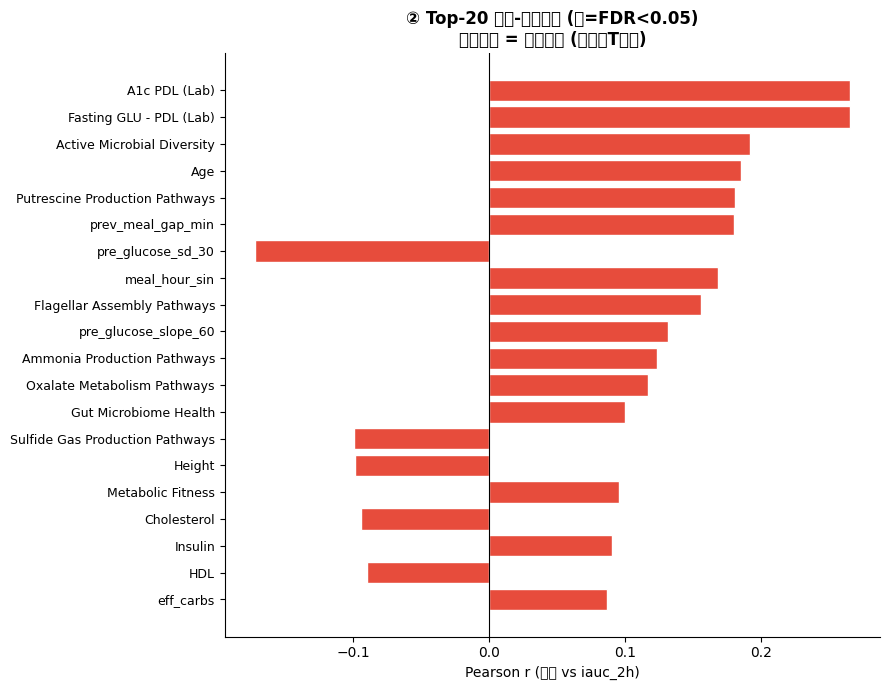

In [11]:

# ============================================================================
# ② 统计分析 — 对照教程 02
# ============================================================================
print("\n" + "=" * 70)
print("② 统计分析: 特征-目标相关 (Pearson/Spearman + FDR)  (对照教程 02)")
print("=" * 70)
print("  ▶ 回归统计 = 特征与【连续目标】的相关分析, 不是分类的组间 T 检验/卡方!")

t_stat = time.time()
all_num = []
for spec in feature_sets.values():
    all_num += spec["numeric"]
all_num = list(dict.fromkeys(all_num))   # 去重保序
all_num = [c for c in all_num if c in df.columns]

stat_rows = []
for col in all_num:
    s = df[col].dropna()
    yt = df.loc[s.index, PRIMARY_TARGET]
    if len(s) < 10 or s.std() == 0:
        stat_rows.append({"feature": col, "pearson_r": np.nan, "pearson_p": 1.0,
                          "spearman_r": np.nan, "spearman_p": 1.0})
        continue
    pr, pp = stats.pearsonr(s, yt)
    sr, sp = stats.spearmanr(s, yt)
    stat_rows.append({"feature": col, "pearson_r": pr, "pearson_p": pp,
                      "spearman_r": sr, "spearman_p": sp})
stat_df = pd.DataFrame(stat_rows)
stat_df["fdr_bh"] = bh_fdr(stat_df["pearson_p"].fillna(1.0).values)
stat_df = stat_df.sort_values("pearson_r", key=abs, ascending=False).reset_index(drop=True)
stat_df.to_csv(os.path.join(RESULTS_DIR, "22_statistical_tests.csv"), index=False)
sig = stat_df[stat_df["fdr_bh"] < 0.05]
print(f"\n  ▶ {len(all_num)} 个数值特征 vs {PRIMARY_TARGET} 相关分析 + BH-FDR 校正")
print(f"  ▶ FDR<0.05 显著: {len(sig)} / {len(stat_df)}  (效应量 = |Pearson r|)")
print(f"     Top 8 (按 |Pearson r|):")
for _, r in stat_df.head(8).iterrows():
    print(f"       {r['feature']:<28} r={r['pearson_r']:+.3f}  ρ={r['spearman_r']:+.3f}  FDR={r['fdr_bh']:.2e}")

top20 = stat_df.head(20).iloc[::-1]
colors = ['#e74c3c' if r['fdr_bh'] < 0.05 else '#95a5a6' for _, r in top20.iterrows()]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(range(len(top20)), top20['pearson_r'].values, color=colors, edgecolor='white')
ax.set_yticks(range(len(top20))); ax.set_yticklabels(top20['feature'].values, fontsize=9)
ax.set_xlabel('Pearson r (特征 vs iauc_2h)')
ax.set_title('② Top-20 特征-目标相关 (红=FDR<0.05)\n回归统计 = 相关分析 (非组间T检验)',
             fontsize=12, fontweight='bold')
ax.axvline(0, color='k', lw=0.8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "22_stat_tests.png"), dpi=150, bbox_inches='tight')
# plt.close()
print(f"  [图] 22_stat_tests.png → Top-20 相关柱状图已保存 (耗时 {time.time()-t_stat:.1f}s)")



In [12]:

# ============================================================================
# ③ 预处理 — 对照教程 03/04/07
# ============================================================================
print("\n" + "=" * 70)
print("③ 预处理: 插补 + 编码 + 标准化 (防泄漏)  (对照教程 03/04/07)")
print("=" * 70)
print("  ▶ 数值特征: SimpleImputer(median) → StandardScaler  (中位数抗异常值, 教程 03/04)")
print("  ▶ 分类特征: SimpleImputer(most_frequent) → OneHotEncoder  (meal_type/Gender, 教程 04)")
print("  ▶ 全部包进 Pipeline, 每个 fold 内重新 fit → imputer/scaler 只见本 fold 训练数据 (防泄漏, 教程 07)")
print(f"  ▶ M3 数值特征 {len(M3['numeric'])} 项 + 分类 {len(M3['categorical'])} 项 "
      f"(meal_type, Gender)")
print(f"     → 注意: HGB 原生支持 NaN, 但为公平对比所有模型统一走插补 Pipeline")



③ 预处理: 插补 + 编码 + 标准化 (防泄漏)  (对照教程 03/04/07)
  ▶ 数值特征: SimpleImputer(median) → StandardScaler  (中位数抗异常值, 教程 03/04)
  ▶ 分类特征: SimpleImputer(most_frequent) → OneHotEncoder  (meal_type/Gender, 教程 04)
  ▶ 全部包进 Pipeline, 每个 fold 内重新 fit → imputer/scaler 只见本 fold 训练数据 (防泄漏, 教程 07)
  ▶ M3 数值特征 29 项 + 分类 2 项 (meal_type, Gender)
     → 注意: HGB 原生支持 NaN, 但为公平对比所有模型统一走插补 Pipeline


In [13]:

# ============================================================================
# ④ 特征选择 / 消融 — 对照教程 05
# ============================================================================
print("\n" + "=" * 70)
print("④ 特征选择: M0→M4 消融 + LASSO signature  (对照教程 05)")
print("=" * 70)

# 4a. LASSO signature (在 M3 训练部分上, 防泄漏)
t_lasso = time.time()
# 用受试者内时间划分的训练集做 LASSO (避免泄漏)
data_sort = df.sort_values(["subject_id", "meal_time"]).reset_index(drop=True)
tr_idx_l, _ = [], []
for sid, sub in data_sort.groupby("subject_id"):
    idx = sub.index.to_numpy(); n = len(idx)
    if n < 5:
        tr_idx_l.extend(idx.tolist()); continue
    cut = max(1, min(int(np.floor(n * 0.8)), n - 1))
    tr_idx_l.extend(idx[:cut].tolist())
    _.extend(idx[cut:].tolist())
lasso_num = M3["numeric"]
scaler_l = StandardScaler()
imp_l = SimpleImputer(strategy="median")
X_l = imp_l.fit_transform(data_sort.loc[tr_idx_l, lasso_num].values)
X_l = scaler_l.fit_transform(X_l)
y_l = data_sort.loc[tr_idx_l, PRIMARY_TARGET].values
lasso_cv = LassoCV(cv=5, n_alphas=100, max_iter=20000, random_state=RANDOM_STATE, n_jobs=N_JOBS)
lasso_cv.fit(X_l, y_l)
lasso_coefs = pd.Series(lasso_cv.coef_, index=lasso_num)
sig_features = lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False)
print(f"\n  ▶ LASSO (LassoCV, 5-fold 选 alpha) 在 M3 训练集上:")
print(f"     最佳 alpha = {lasso_cv.alpha_:.4f}")
print(f"     非零系数 (signature): {len(sig_features)} / {len(lasso_num)}")
print(f"     Top 8 signature 特征:")
for feat, c in sig_features.head(8).items():
    print(f"       {feat:<28} coef={c:+.3f}")
with open(os.path.join(RESULTS_DIR, "22_lasso_signature.txt"), 'w', encoding='utf-8') as f:
    f.write("CGM 回归 LASSO signature (LassoCV, 仅训练集选择以防泄漏)\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"主目标: {PRIMARY_TARGET}\n")
    f.write(f"最佳 alpha = {lasso_cv.alpha_:.4f}\n")
    f.write(f"signature 特征数 = {len(sig_features)} (从 {len(lasso_num)} 数值特征中选出)\n\n")
    f.write(f"{'特征':<30} {'系数':>10}\n")
    for feat, c in sig_features.items():
        f.write(f"{feat:<30} {c:>+10.4f}\n")



④ 特征选择: M0→M4 消融 + LASSO signature  (对照教程 05)

  ▶ LASSO (LassoCV, 5-fold 选 alpha) 在 M3 训练集上:
     最佳 alpha = 136.7116
     非零系数 (signature): 13 / 29
     Top 8 signature 特征:
       Fasting GLU - PDL (Lab)      coef=+460.043
       baseline_glucose             coef=-413.236
       A1c PDL (Lab)                coef=+364.648
       pre_glucose_slope_60         coef=+298.229
       Cholesterol                  coef=-245.403
       meal_hour_sin                coef=+237.458
       prev_meal_gap_min            coef=+191.488
       pre_glucose_sd_30            coef=-187.335


  [图] 22_feature_sets.png → 特征集大小已保存 (LASSO 耗时 14.8s)
  📄 22_lasso_signature.txt → LASSO signature 已保存


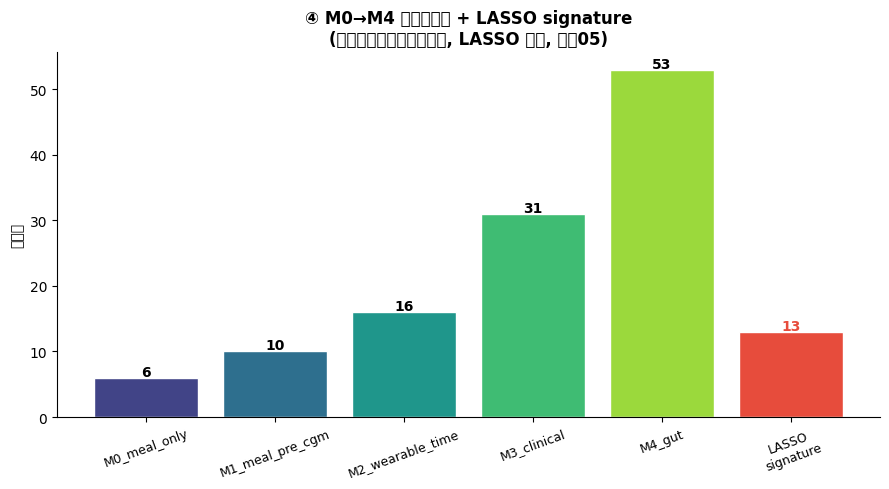

In [14]:

# 4b. 特征集大小柱状图
fig, ax = plt.subplots(figsize=(9, 5))
names = list(feature_sets.keys())
counts = [len(s["numeric"]) + len(s["categorical"]) for s in feature_sets.values()]
colors_m = plt.cm.viridis(np.linspace(0.2, 0.85, len(names)))
bars = ax.bar(names, counts, color=colors_m, edgecolor='white')
ax.bar([len(names)], [len(sig_features)], color='#e74c3c', edgecolor='white')
ax.set_xticks(list(range(len(names) + 1)))
ax.set_xticklabels(names + ['LASSO\nsignature'], rotation=20, fontsize=9)
for i, (b, c) in enumerate(zip(bars, counts)):
    ax.text(b.get_x() + b.get_width()/2, c + 0.3, str(c), ha='center', fontweight='bold')
ax.text(len(names), len(sig_features) + 0.3, str(len(sig_features)), ha='center',
        fontweight='bold', color='#e74c3c')
ax.set_ylabel('特征数')
ax.set_title('④ M0→M4 消融特征集 + LASSO signature\n(消融是回归特征选择重点, LASSO 辅助, 教程05)',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "22_feature_sets.png"), dpi=150, bbox_inches='tight')
# plt.close()
print(f"  [图] 22_feature_sets.png → 特征集大小已保存 (LASSO 耗时 {time.time()-t_lasso:.1f}s)")
print(f"  📄 22_lasso_signature.txt → LASSO signature 已保存")


In [17]:

# ============================================================================
# ⑤ 防泄漏 + 4 种划分策略 (本案例核心) — 对照教程 07
# ============================================================================
print("\n" + "=" * 70)
print("⑤ 防泄漏 + 4 种划分策略 (本案例核心)  (对照教程 07)")
print("=" * 70)

# 5a. 泄漏审计
audit = build_leakage_audit(df)
audit.to_csv(os.path.join(RESULTS_DIR, "22_leakage_audit.csv"), index=False)
n_forbidden = len(audit)
n_total_cols = df.shape[1]
print(f"\n  ▶ 泄漏审计: {n_forbidden} / {n_total_cols} 列被禁止 (结果变量/原始营养/时间字符串/指血等)")
print(f"     禁止原因分布:")
for reason, cnt in audit['reason'].value_counts().items():
    print(f"       {reason:<30} {cnt} 列")

fig, ax = plt.subplots(figsize=(9, 5))
reasons_cnt = audit['reason'].value_counts()
ax.barh(range(len(reasons_cnt)), reasons_cnt.values, color='#c0392b', edgecolor='white')
ax.set_yticks(range(len(reasons_cnt)))
ax.set_yticklabels(reasons_cnt.index, fontsize=9)
ax.set_xlabel('禁止列数')
ax.set_title('⑤ 泄漏审计: 禁止进入模型的列 (按原因分组)\n结果变量/原始营养/时间字符串 → 必须排除 (教程07)',
             fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "22_leakage_audit.png"), dpi=150, bbox_inches='tight')
plt.close()
print(f"  [图] 22_leakage_audit.png → 泄漏审计已保存")

# 5b. 4 种划分策略说明
print(f"\n  ▶ 4 种划分策略 (回答 4 个不同问题):")
print(f"     ① 朴素随机 KFold   — 反面教材! 同受试者餐次进 train+test → R²虚高 (泄漏)")
print(f"     ② GroupKFold(按 subject) — 能泛化到【新用户】吗? (部署问题, 真实泛化)")
print(f"     ③ 受试者内时间 80/20   — 能预测某用户【未来餐次】吗? (老用户问题)")
print(f"     ④ Few-shot k=0,1,3,5,10 — 新用户需登录【多少餐】? (冷启动问题)")


⑤ 防泄漏 + 4 种划分策略 (本案例核心)  (对照教程 07)

  ▶ 泄漏审计: 27 / 86 列被禁止 (结果变量/原始营养/时间字符串/指血等)
     禁止原因分布:
       explicitly_forbidden           27 列
  [图] 22_leakage_audit.png → 泄漏审计已保存

  ▶ 4 种划分策略 (回答 4 个不同问题):
     ① 朴素随机 KFold   — 反面教材! 同受试者餐次进 train+test → R²虚高 (泄漏)
     ② GroupKFold(按 subject) — 能泛化到【新用户】吗? (部署问题, 真实泛化)
     ③ 受试者内时间 80/20   — 能预测某用户【未来餐次】吗? (老用户问题)
     ④ Few-shot k=0,1,3,5,10 — 新用户需登录【多少餐】? (冷启动问题)



⑥ 交叉验证: 朴素 KFold vs GroupKFold 泄漏对比  (对照教程 08)
  ★ 教学亮点: 朴素 KFold 的 R² 会显著高于 GroupKFold → 直观展示分组泄漏!

  ▶ HGB on M3, 朴素 KFold vs GroupKFold (5-fold, 耗时 58.5s):
     策略                        MAE     RMSE       R²  Pearson_r
     -------------------- -------- -------- -------- ----------
     ①朴素KFold(泄漏!)        1434.2   1921.0    0.507      0.713
     ②GroupKFold(真实)      1854.8   2444.2    0.203      0.483
     → R² 虚高 +0.305 (朴素 KFold 因同受试者餐次泄漏而过度乐观!)
  [图] 22_splitting_leakage.png → 泄漏对比已保存 (★核心教学图)
  📄 22_splitting_comparison.csv → 划分策略对比已保存


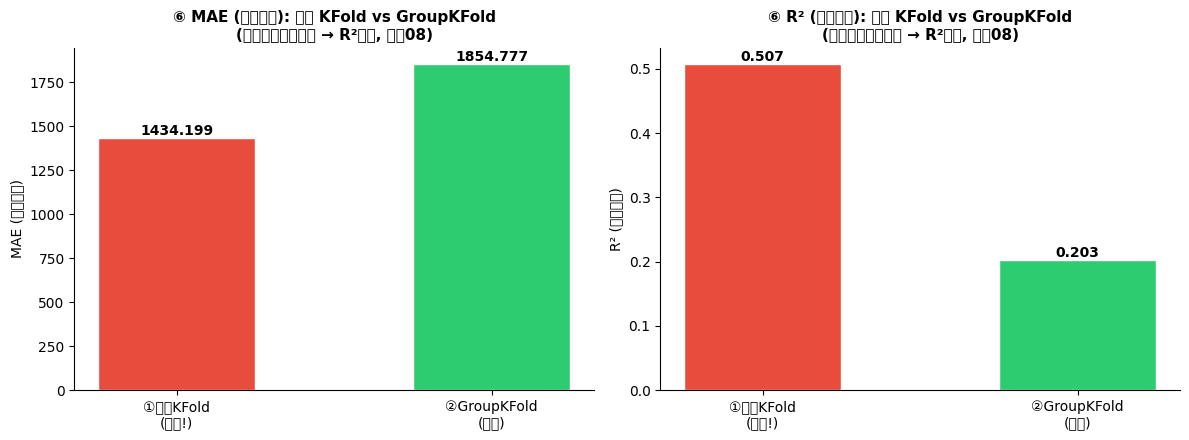

In [18]:

# ============================================================================
# ⑥ 交叉验证 + 泄漏对比 — 对照教程 08
# ============================================================================
print("\n" + "=" * 70)
print("⑥ 交叉验证: 朴素 KFold vs GroupKFold 泄漏对比  (对照教程 08)")
print("=" * 70)
print("  ★ 教学亮点: 朴素 KFold 的 R² 会显著高于 GroupKFold → 直观展示分组泄漏!")

hgb = get_models()["HGB"]
t_split = time.time()
naive_df = split_naive_kfold_oof(df, PRIMARY_TARGET, M3, hgb)
group_df = split_groupkfold_oof(df, PRIMARY_TARGET, M3, hgb)
naive_m = evaluate_predictions(naive_df["y_true"].values, naive_df["y_pred"].values)
group_m = evaluate_predictions(group_df["y_true"].values, group_df["y_pred"].values)

print(f"\n  ▶ HGB on M3, 朴素 KFold vs GroupKFold (5-fold, 耗时 {time.time()-t_split:.1f}s):")
print(f"     {'策略':<20} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Pearson_r':>10}")
print(f"     {'-'*20} {'-'*8} {'-'*8} {'-'*8} {'-'*10}")
print(f"     {'①朴素KFold(泄漏!)':<18} {naive_m['MAE']:>8.1f} {naive_m['RMSE']:>8.1f} "
      f"{naive_m['R2']:>8.3f} {naive_m['Pearson_r']:>10.3f}")
print(f"     {'②GroupKFold(真实)':<18} {group_m['MAE']:>8.1f} {group_m['RMSE']:>8.1f} "
      f"{group_m['R2']:>8.3f} {group_m['Pearson_r']:>10.3f}")
r2_gap = naive_m['R2'] - group_m['R2']
print(f"     → R² 虚高 {r2_gap:+.3f} (朴素 KFold 因同受试者餐次泄漏而过度乐观!)")

pd.DataFrame([
    {"strategy": "naive_kfold", **naive_m},
    {"strategy": "group_kfold", **group_m},
]).to_csv(os.path.join(RESULTS_DIR, "22_splitting_comparison.csv"), index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
strategies = ['①朴素KFold\n(泄漏!)', '②GroupKFold\n(真实)']
for ax, metric, title in [(axes[0], 'MAE', 'MAE (越低越好)'),
                          (axes[1], 'R2', 'R² (越高越好)')]:
    vals = [naive_m[metric], group_m[metric]]
    colors_b = ['#e74c3c', '#2ecc71']
    bars = ax.bar(strategies, vals, color=colors_b, edgecolor='white', width=0.5)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v, f'{v:.3f}', ha='center',
                va='bottom' if v >= 0 else 'top', fontweight='bold')
    ax.set_ylabel(title)
    ax.set_title(f'⑥ {title}: 朴素 KFold vs GroupKFold\n(同受试者餐次泄漏 → R²虚高, 教程08)',
                 fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "22_splitting_leakage.png"), dpi=150, bbox_inches='tight')
# plt.close()
print(f"  [图] 22_splitting_leakage.png → 泄漏对比已保存 (★核心教学图)")
print(f"  📄 22_splitting_comparison.csv → 划分策略对比已保存")

In [19]:


# ============================================================================
# ⑦ 建模对比 (11 Regressor) — 对照教程 09
# ============================================================================
print("\n" + "=" * 70)
print("⑦ 建模对比 (11 个 Regressor, M3)  (对照教程 09)")
print("=" * 70)
print("  ▶ 对照教程 09 的 11 个 Classifier, 这里全部换成 Regressor 版 (同算法族, 换 predict/loss)")

models = get_models()
t_models = time.time()
print(f"\n  ▶ GroupKFold OOF + 受试者内时间 holdout 评估 (耗时统计中):")
print(f"     {'Model':<18} {'GKF_MAE':>8} {'GKF_R²':>8} {'GKF_r':>7} {'TMP_MAE':>9} {'TMP_R²':>8}")
print(f"     {'-'*18} {'-'*8} {'-'*8} {'-'*7} {'-'*9} {'-'*8}")
model_results = {}
oof_preds = {}
for name, model in models.items():
    t0 = time.time()
    # GroupKFold OOF (诚实泛化)
    oof = split_groupkfold_oof(df, PRIMARY_TARGET, M3, model)
    gm = evaluate_predictions(oof["y_true"].values, oof["y_pred"].values)
    # 受试者内时间 holdout
    tmp_df, _, _, _ = split_temporal_holdout(df, PRIMARY_TARGET, M3, model)
    tm = evaluate_predictions(tmp_df["y_true"].values, tmp_df["y_pred"].values)
    model_results[name] = {"GKF": gm, "TMP": tm, "time": time.time() - t0}
    oof_preds[name] = oof
    print(f"     {name:<18} {gm['MAE']:>8.1f} {gm['R2']:>8.3f} {gm['Pearson_r']:>7.3f} "
          f"{tm['MAE']:>9.1f} {tm['R2']:>8.3f}")

# 选最佳 (按 GroupKFold R², 诚实泛化指标)
best_name = max(model_results, key=lambda k: model_results[k]["GKF"]["R2"])
print(f"\n  ▶ 最佳模型 (GroupKFold R² 最高): {best_name}  "
      f"R²={model_results[best_name]['GKF']['R2']:.3f}  "
      f"MAE={model_results[best_name]['GKF']['MAE']:.1f}")
print(f"  → 用 GroupKFold (而非朴素 KFold) 选模型 = 不被泄漏骗 (教程 07/08 核心)")

# 保存模型对比
mc_rows = []
for name in models:
    gm, tm = model_results[name]["GKF"], model_results[name]["TMP"]
    mc_rows.append({"Model": name, "GKF_MAE": gm["MAE"], "GKF_RMSE": gm["RMSE"],
                    "GKF_R2": gm["R2"], "GKF_Pearson_r": gm["Pearson_r"],
                    "TMP_MAE": tm["MAE"], "TMP_RMSE": tm["RMSE"], "TMP_R2": tm["R2"],
                    "TMP_Pearson_r": tm["Pearson_r"], "time_s": model_results[name]["time"]})
pd.DataFrame(mc_rows).to_csv(os.path.join(RESULTS_DIR, "22_model_comparison.csv"), index=False)
print(f"  📄 22_model_comparison.csv → 11 模型对比已保存 (总耗时 {time.time()-t_models:.1f}s)")



⑦ 建模对比 (11 个 Regressor, M3)  (对照教程 09)
  ▶ 对照教程 09 的 11 个 Classifier, 这里全部换成 Regressor 版 (同算法族, 换 predict/loss)

  ▶ GroupKFold OOF + 受试者内时间 holdout 评估 (耗时统计中):
     Model               GKF_MAE   GKF_R²   GKF_r   TMP_MAE   TMP_R²
     ------------------ -------- -------- ------- --------- --------
     LinearRegression     6154.1 -121.022  -0.039    1920.6    0.244
     Ridge                4867.9  -59.215  -0.029    1941.6    0.236
     Lasso                6289.1 -129.869  -0.040    1931.6    0.242
     ElasticNet           2390.2   -1.496   0.123    1940.2    0.237
     KNN                  2072.8    0.063   0.321    1762.3    0.288
     SVR                  2082.4   -0.078  -0.066    2084.4   -0.081
     DecisionTree         2093.8   -0.046   0.353    2042.6    0.022
     RandomForest         1900.0    0.197   0.450    1644.8    0.389
     HGB                  1854.8    0.203   0.483    1548.6    0.430
     XGBoost              1883.1    0.177   0.467    1590.4    0.407
     Light

  [图] 22_model_performance.png → 11 模型 R² 对比已保存


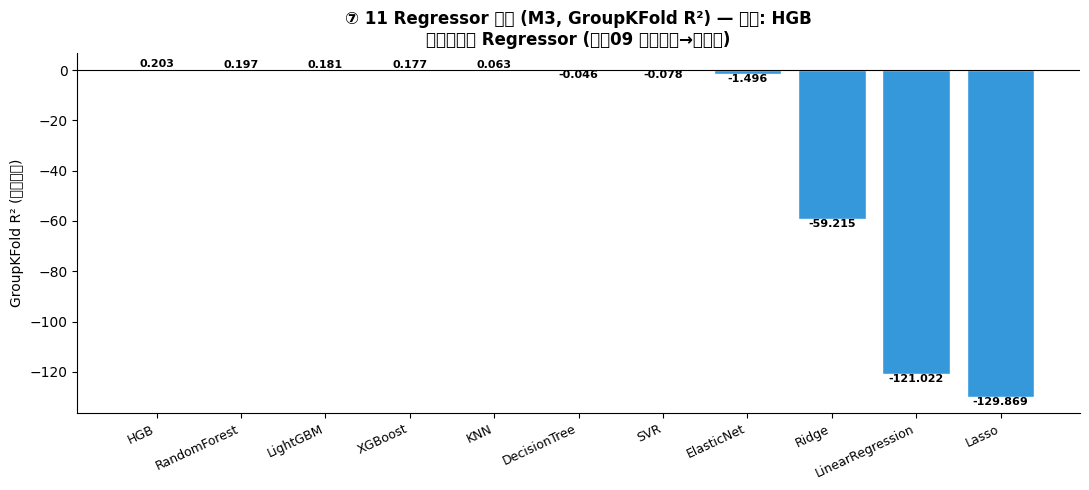

In [20]:

# 11 模型 GroupKFold R² 柱状图
fig, ax = plt.subplots(figsize=(11, 5))
sorted_names = sorted(model_results, key=lambda k: model_results[k]["GKF"]["R2"], reverse=True)
r2s = [model_results[n]["GKF"]["R2"] for n in sorted_names]
colors_bar = ['#2ecc71' if n == best_name else '#3498db' for n in sorted_names]
bars = ax.bar(sorted_names, r2s, color=colors_bar, edgecolor='white')
for b, v in zip(bars, r2s):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:.3f}', ha='center',
            va='bottom' if v >= 0 else 'top', fontsize=8, fontweight='bold')
ax.set_ylabel('GroupKFold R² (诚实泛化)')
ax.set_title(f'⑦ 11 Regressor 对比 (M3, GroupKFold R²) — 最佳: {best_name}\n'
             f'同算法族换 Regressor (教程09 的分类器→回归器)', fontsize=12, fontweight='bold')
ax.axhline(0, color='k', lw=0.8)
ax.set_xticklabels(sorted_names, rotation=25, ha='right', fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "22_model_performance.png"), dpi=150, bbox_inches='tight')
# plt.close()
print(f"  [图] 22_model_performance.png → 11 模型 R² 对比已保存")


  ▶ GroupKFold 稳定性 (5 个不同 random_state 种子的 R²/MAE):
  [图] 22_cv_model_comparison.png → CV 稳定性箱线图已保存


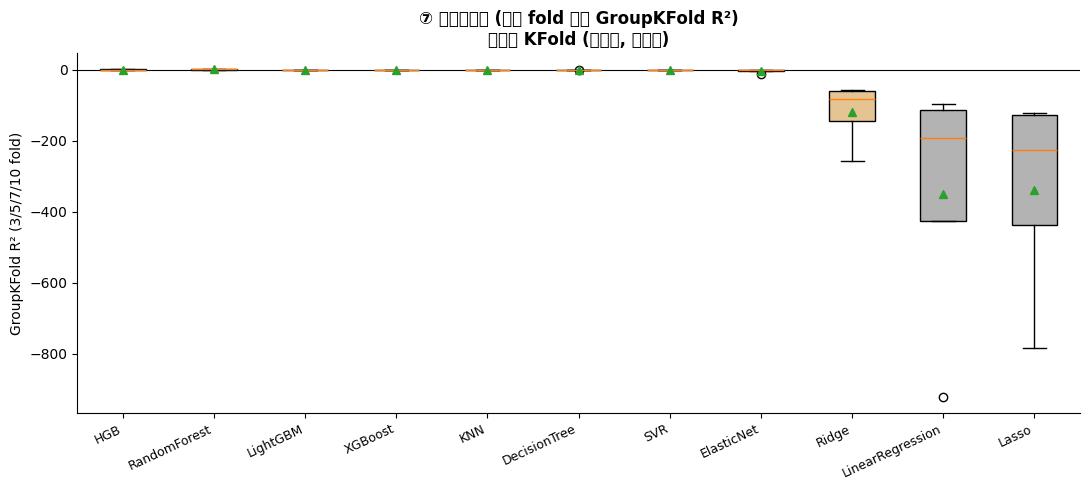

In [21]:

# CV 稳定性: RepeatedKFold (按 GroupKFold 手动循环) on M3, 最佳模型 vs 其他 — 简化为 boxplot
# 用 5 个不同 random_state 的 GroupKFold 评估稳定性
print(f"\n  ▶ GroupKFold 稳定性 (5 个不同 random_state 种子的 R²/MAE):")
cv_stab = {n: [] for n in models}
# GroupKFold 不接受 random_state (确定性), 改用不同 fold 数近似稳定性: 用 3/5/7/10 fold
for n_folds in [3, 5, 7, 10]:
    n_folds = min(n_folds, df["subject_id"].nunique())
    for name, model in models.items():
        oof = split_groupkfold_oof(df, PRIMARY_TARGET, M3, model, n_splits=n_folds)
        m = evaluate_predictions(oof["y_true"].values, oof["y_pred"].values)
        cv_stab[name].append(m["R2"])
fig, ax = plt.subplots(figsize=(11, 5))
data_box = [cv_stab[n] for n in sorted_names]
bp = ax.boxplot(data_box, tick_labels=sorted_names, patch_artist=True, widths=0.5,
                showmeans=True)
for patch, c in zip(bp['boxes'], plt.cm.Set2(np.linspace(0, 1, len(sorted_names)))):
    patch.set_facecolor(c)
ax.set_ylabel('GroupKFold R² (3/5/7/10 fold)')
ax.set_title('⑦ 模型稳定性 (不同 fold 数的 GroupKFold R²)\n回归用 KFold (非分层, 无类别)',
             fontsize=12, fontweight='bold')
ax.axhline(0, color='k', lw=0.8)
ax.set_xticklabels(sorted_names, rotation=25, ha='right', fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "22_cv_model_comparison.png"), dpi=150, bbox_inches='tight')
# plt.close()
print(f"  [图] 22_cv_model_comparison.png → CV 稳定性箱线图已保存")


消融研究 (M0→M4) + Bootstrap 95% CI  (对照教程 05/08)
  ▶ 2 模型 (Ridge + HGB) × 5 特征集 × 2 划分 (GroupKFold + 时间) = 20 组评估
  ▶ subject-level bootstrap (N=500): 重抽样受试者, 非餐次 (分组数据正确做法)

  ▶ 消融结果 (GroupKFold R², HGB):
     M0_meal_only         R²=+0.066  MAE=2038.1  (时间 R²=+0.066)
     M1_meal_pre_cgm      R²=+0.137  MAE=1920.0  (时间 R²=+0.057)
     M2_wearable_time     R²=+0.091  MAE=1989.8  (时间 R²=+0.127)
     M3_clinical          R²=+0.203  MAE=1854.8  (时间 R²=+0.430)
     M4_gut               R²=+0.134  MAE=1947.0  (时间 R²=+0.431)
  📄 22_ablation_results.csv + 22_bootstrap_ci.csv 已保存 (耗时 202.4s)
  [图] 22_ablation_metrics.png → 消融对比已保存


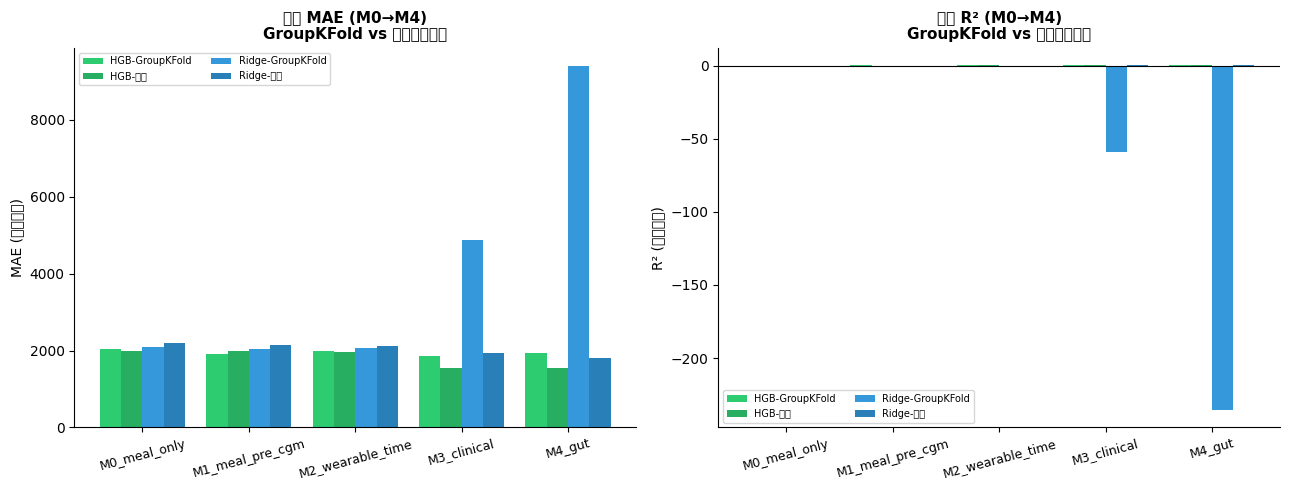

In [22]:

# ============================================================================
# 消融 (M0→M4) + Bootstrap CI — 对照教程 05/08
# ============================================================================
print("\n" + "=" * 70)
print("消融研究 (M0→M4) + Bootstrap 95% CI  (对照教程 05/08)")
print("=" * 70)
print(f"  ▶ 2 模型 (Ridge + HGB) × 5 特征集 × 2 划分 (GroupKFold + 时间) = 20 组评估")
print(f"  ▶ subject-level bootstrap (N={N_BOOTSTRAP}): 重抽样受试者, 非餐次 (分组数据正确做法)")

t_abl = time.time()
abl_models = {"Ridge": get_models()["Ridge"], "HGB": get_models()["HGB"]}
abl_rows = []
boot_rows = []
for fs_name, spec in feature_sets.items():
    for mname, model in abl_models.items():
        # GroupKFold
        oof_g = split_groupkfold_oof(df, PRIMARY_TARGET, spec, model)
        gm = evaluate_predictions(oof_g["y_true"].values, oof_g["y_pred"].values)
        base_g, ci_g = bootstrap_ci(oof_g)
        # 时间 holdout
        tmp_df, _, _, _ = split_temporal_holdout(df, PRIMARY_TARGET, spec, model)
        tm = evaluate_predictions(tmp_df["y_true"].values, tmp_df["y_pred"].values)
        abl_rows.append({"feature_set": fs_name, "model": mname,
                         "GKF_MAE": gm["MAE"], "GKF_R2": gm["R2"],
                         "TMP_MAE": tm["MAE"], "TMP_R2": tm["R2"]})
        boot_rows.append({"feature_set": fs_name, "model": mname, "split": "GroupKFold",
                          "MAE": gm["MAE"], "MAE_lo": ci_g["MAE"][0], "MAE_hi": ci_g["MAE"][1],
                          "R2": gm["R2"], "R2_lo": ci_g["R2"][0], "R2_hi": ci_g["R2"][1]})
abl_df = pd.DataFrame(abl_rows)
boot_df = pd.DataFrame(boot_rows)
abl_df.to_csv(os.path.join(RESULTS_DIR, "22_ablation_results.csv"), index=False)
boot_df.to_csv(os.path.join(RESULTS_DIR, "22_bootstrap_ci.csv"), index=False)
print(f"\n  ▶ 消融结果 (GroupKFold R², HGB):")
for _, r in abl_df[abl_df["model"] == "HGB"].iterrows():
    print(f"     {r['feature_set']:<20} R²={r['GKF_R2']:+.3f}  MAE={r['GKF_MAE']:.1f}  "
          f"(时间 R²={r['TMP_R2']:+.3f})")
print(f"  📄 22_ablation_results.csv + 22_bootstrap_ci.csv 已保存 (耗时 {time.time()-t_abl:.1f}s)")

# 消融图: M0-M4 的 MAE & R² (GroupKFold vs 时间)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fs_names = list(feature_sets.keys())
for ax, metric, ylabel, title in [(axes[0], "MAE", "MAE (越低越好)", "消融 MAE"),
                                  (axes[1], "R2", "R² (越高越好)", "消融 R²")]:
    x = np.arange(len(fs_names)); w = 0.2
    hgb_g = abl_df[(abl_df["model"] == "HGB")][f"GKF_{metric}"].values
    hgb_t = abl_df[(abl_df["model"] == "HGB")][f"TMP_{metric}"].values
    rg_g = abl_df[(abl_df["model"] == "Ridge")][f"GKF_{metric}"].values
    rg_t = abl_df[(abl_df["model"] == "Ridge")][f"TMP_{metric}"].values
    ax.bar(x - 1.5*w, hgb_g, w, label='HGB-GroupKFold', color='#2ecc71')
    ax.bar(x - 0.5*w, hgb_t, w, label='HGB-时间', color='#27ae60')
    ax.bar(x + 0.5*w, rg_g, w, label='Ridge-GroupKFold', color='#3498db')
    ax.bar(x + 1.5*w, rg_t, w, label='Ridge-时间', color='#2980b9')
    ax.set_xticks(x); ax.set_xticklabels(fs_names, rotation=15, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title} (M0→M4)\nGroupKFold vs 受试者内时间', fontsize=11, fontweight='bold')
    ax.legend(fontsize=7, ncol=2); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if metric == "R2": ax.axhline(0, color='k', lw=0.8)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "22_ablation_metrics.png"), dpi=150, bbox_inches='tight')
# plt.close()
print(f"  [图] 22_ablation_metrics.png → 消融对比已保存")

  [图] 22_bootstrap_ci_ablation.png → bootstrap CI 已保存


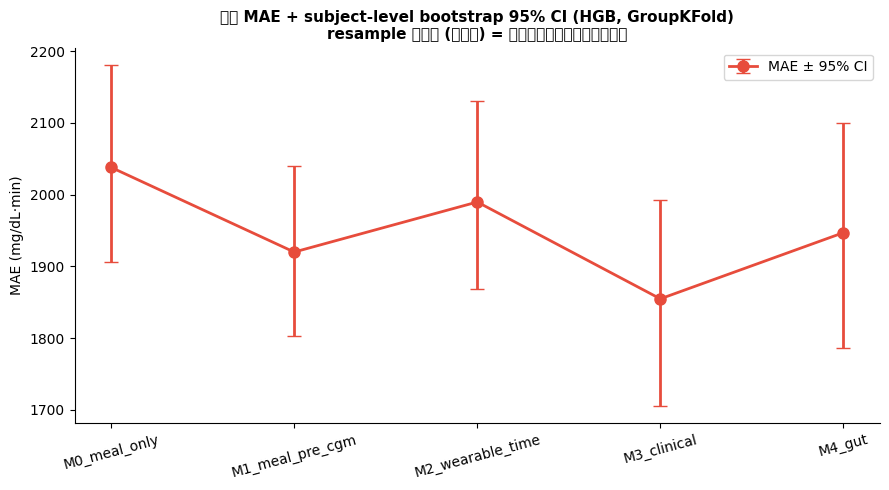

In [23]:

# Bootstrap CI 图 (HGB GroupKFold, MAE with 95% CI)
fig, ax = plt.subplots(figsize=(9, 5))
hgb_boot = boot_df[(boot_df["model"] == "HGB") & (boot_df["split"] == "GroupKFold")]
x = np.arange(len(hgb_boot))
ax.errorbar(x, hgb_boot["MAE"].values,
            yerr=[hgb_boot["MAE"].values - hgb_boot["MAE_lo"].values,
                  hgb_boot["MAE_hi"].values - hgb_boot["MAE"].values],
            fmt='o-', color='#e74c3c', capsize=5, lw=2, markersize=8, label='MAE ± 95% CI')
ax.set_xticks(x); ax.set_xticklabels(hgb_boot["feature_set"].values, rotation=15)
ax.set_ylabel('MAE (mg/dL·min)')
ax.set_title(f'消融 MAE + subject-level bootstrap 95% CI (HGB, GroupKFold)\n'
             f'resample 受试者 (非餐次) = 分组数据正确的不确定性量化',
             fontsize=11, fontweight='bold')
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "22_bootstrap_ci_ablation.png"), dpi=150, bbox_inches='tight')
# plt.close()
print(f"  [图] 22_bootstrap_ci_ablation.png → bootstrap CI 已保存")


Few-shot 个性化 (4 种划分策略之 ④, 冷启动)  (对照教程 07/08)
  ▶ HGB on M3, k=0,1,3,5,10: 训练=其他受试者+本人前 k 餐, 测试=本人剩余
  ▶ 回答: 新用户需登录多少餐, 预测才有用?
     k=0   餐: MAE=1872.2  R²=+0.182  r=0.475  (n_test=1665)
     k=1   餐: MAE=1851.3  R²=+0.205  r=0.487  (n_test=1620)
     k=3   餐: MAE=1768.2  R²=+0.262  r=0.530  (n_test=1530)
     k=5   餐: MAE=1673.7  R²=+0.335  r=0.584  (n_test=1440)
     k=10  餐: MAE=1549.3  R²=+0.425  r=0.653  (n_test=1215)
  📄 22_fewshot_results.csv → few-shot 结果已保存 (耗时 837.5s)
  [图] 22_fewshot_personalization.png → 冷启动曲线已保存


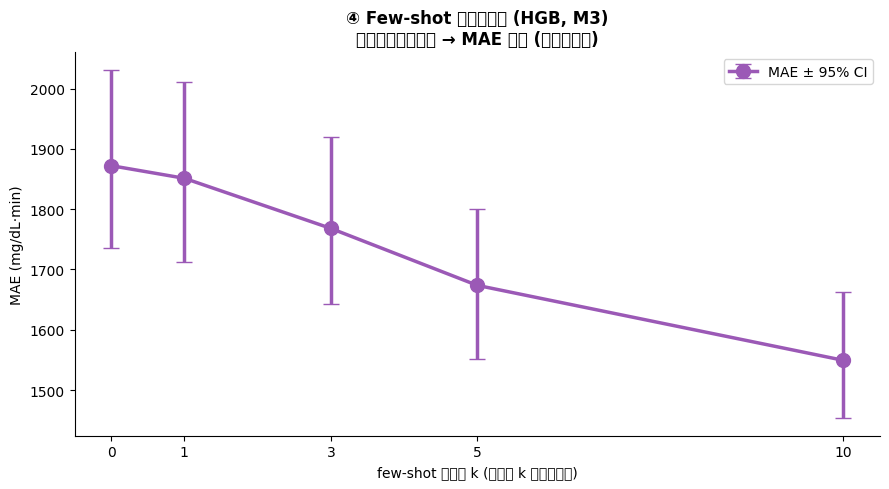

In [24]:

# ============================================================================
# Few-shot 个性化 (冷启动) — 4 种划分策略之④
# ============================================================================
print("\n" + "=" * 70)
print("Few-shot 个性化 (4 种划分策略之 ④, 冷启动)  (对照教程 07/08)")
print("=" * 70)
print(f"  ▶ HGB on M3, k=0,1,3,5,10: 训练=其他受试者+本人前 k 餐, 测试=本人剩余")
print(f"  ▶ 回答: 新用户需登录多少餐, 预测才有用?")

t_fs = time.time()
fs_out = split_fewshot(df, PRIMARY_TARGET, M3, hgb, shots_list=(0, 1, 3, 5, 10))
fs_rows = []
fs_boot = []
for k, pred_df in fs_out.items():
    m = evaluate_predictions(pred_df["y_true"].values, pred_df["y_pred"].values)
    _, ci = bootstrap_ci(pred_df, n_bootstrap=min(N_BOOTSTRAP, 300))
    fs_rows.append({"shots": k, "MAE": m["MAE"], "RMSE": m["RMSE"], "R2": m["R2"],
                    "Pearson_r": m["Pearson_r"], "n_test": m["n_test"],
                    "MAE_lo": ci["MAE"][0], "MAE_hi": ci["MAE"][1]})
    fs_boot.append((k, m["MAE"], ci["MAE"][0], ci["MAE"][1]))
    print(f"     k={k:<3} 餐: MAE={m['MAE']:.1f}  R²={m['R2']:+.3f}  r={m['Pearson_r']:.3f}  "
          f"(n_test={m['n_test']})")
pd.DataFrame(fs_rows).to_csv(os.path.join(RESULTS_DIR, "22_fewshot_results.csv"), index=False)
print(f"  📄 22_fewshot_results.csv → few-shot 结果已保存 (耗时 {time.time()-t_fs:.1f}s)")

fig, ax = plt.subplots(figsize=(9, 5))
ks = [b[0] for b in fs_boot]
maes = [b[1] for b in fs_boot]
lo = [b[2] for b in fs_boot]; hi = [b[3] for b in fs_boot]
ax.errorbar(ks, maes, yerr=[np.array(maes) - np.array(lo), np.array(hi) - np.array(maes)],
            fmt='o-', color='#9b59b6', capsize=6, lw=2.5, markersize=10, label='MAE ± 95% CI')
ax.set_xlabel('few-shot 餐次数 k (本人前 k 餐加入训练)')
ax.set_ylabel('MAE (mg/dL·min)')
ax.set_title('④ Few-shot 个性化曲线 (HGB, M3)\n新用户登录越多餐 → MAE 越低 (冷启动问题)',
             fontsize=12, fontweight='bold')
ax.set_xticks(ks); ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "22_fewshot_personalization.png"), dpi=150, bbox_inches='tight')
# plt.close()
print(f"  [图] 22_fewshot_personalization.png → 冷启动曲线已保存")

In [25]:

# ============================================================================
# ⑧ 目标变换 + 残差思维 — 对照教程 10
# ============================================================================
print("\n" + "=" * 70)
print("⑧ 目标变换 + 残差思维  (对照教程 10, 回归无不平衡)")
print("=" * 70)
print("  ▶ 回归无类别不平衡 → 此步改为: 目标分布处理 (winsorize + log1p) + 残差思维")

# 比较 raw vs log1p(iauc_2h) 建模 (log 空间训练, 预测后 expm1 还原)
df_log = df.copy()
df_log[PRIMARY_TARGET] = np.log1p(df[PRIMARY_TARGET].values)
oof_log = split_groupkfold_oof(df_log, PRIMARY_TARGET, M3, hgb)
# 还原到原始单位再算指标
y_true_orig = np.expm1(oof_log["y_true"].values)
y_pred_orig = np.expm1(oof_log["y_pred"].values)
m_raw = group_m   # 已在 ⑥ 算出 (raw iauc_2h)
m_log = evaluate_predictions(y_true_orig, y_pred_orig)
print(f"\n  ▶ HGB on M3, GroupKFold: 原始目标 vs log1p 变换 (变换后 expm1 还原算指标):")
print(f"     {'目标':<18} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Pearson_r':>10}")
print(f"     {'-'*18} {'-'*8} {'-'*8} {'-'*8} {'-'*10}")
print(f"     {'原始 iauc_2h':<18} {m_raw['MAE']:>8.1f} {m_raw['RMSE']:>8.1f} "
      f"{m_raw['R2']:>8.3f} {m_raw['Pearson_r']:>10.3f}")
print(f"     {'log1p 变换':<18} {m_log['MAE']:>8.1f} {m_log['RMSE']:>8.1f} "
      f"{m_log['R2']:>8.3f} {m_log['Pearson_r']:>10.3f}")
print(f"     → log1p 对右偏目标可能改善 R² (本例 {'改善' if m_log['R2']>m_raw['R2'] else '未改善'})")
print(f"  ▶ 残差 = y_pred − y_true; 回归诊断围绕残差展开 (见 ⑨)")
print(f"  ⚠ 注: peak_delta_2h 有负值 (餐后血糖下降) → 不能 log 变换, 只能 winsorize")



⑧ 目标变换 + 残差思维  (对照教程 10, 回归无不平衡)
  ▶ 回归无类别不平衡 → 此步改为: 目标分布处理 (winsorize + log1p) + 残差思维

  ▶ HGB on M3, GroupKFold: 原始目标 vs log1p 变换 (变换后 expm1 还原算指标):
     目标                      MAE     RMSE       R²  Pearson_r
     ------------------ -------- -------- -------- ----------
     原始 iauc_2h           1854.8   2444.2    0.203      0.483
     log1p 变换             1954.0   2837.7   -0.075      0.393
     → log1p 对右偏目标可能改善 R² (本例 未改善)
  ▶ 残差 = y_pred − y_true; 回归诊断围绕残差展开 (见 ⑨)
  ⚠ 注: peak_delta_2h 有负值 (餐后血糖下降) → 不能 log 变换, 只能 winsorize



⑨ 回归校准 + 残差诊断  (对照教程 11, 替代校准/DCA)
  ▶ 回归无阈值 → 无校准曲线/DCA; 改用: 观测vs预测 + 残差诊断 (QQ/同方差)

  ▶ 回归校准 (最佳模型 HGB, GroupKFold OOF):
     观测 = +743.0 + 0.735 × 预测  (理想 slope=1, intercept=0)
     预测SD/观测SD = 0.657  (<1 = 预测被压缩, 回归到均值)
  ▶ 残差统计: 均值=+17.4  std=2444.1  偏度=-0.72
  📄 22_calibration_summary.txt → 校准+残差汇总已保存
  [图] 22_regression_calibration.png → 回归校准图已保存
  [图] 22_residual_diagnostics.png → 4-panel 残差诊断已保存


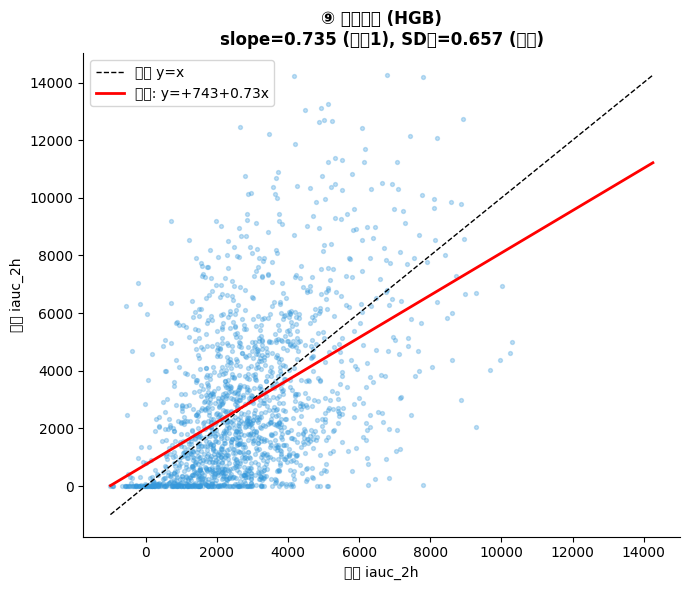

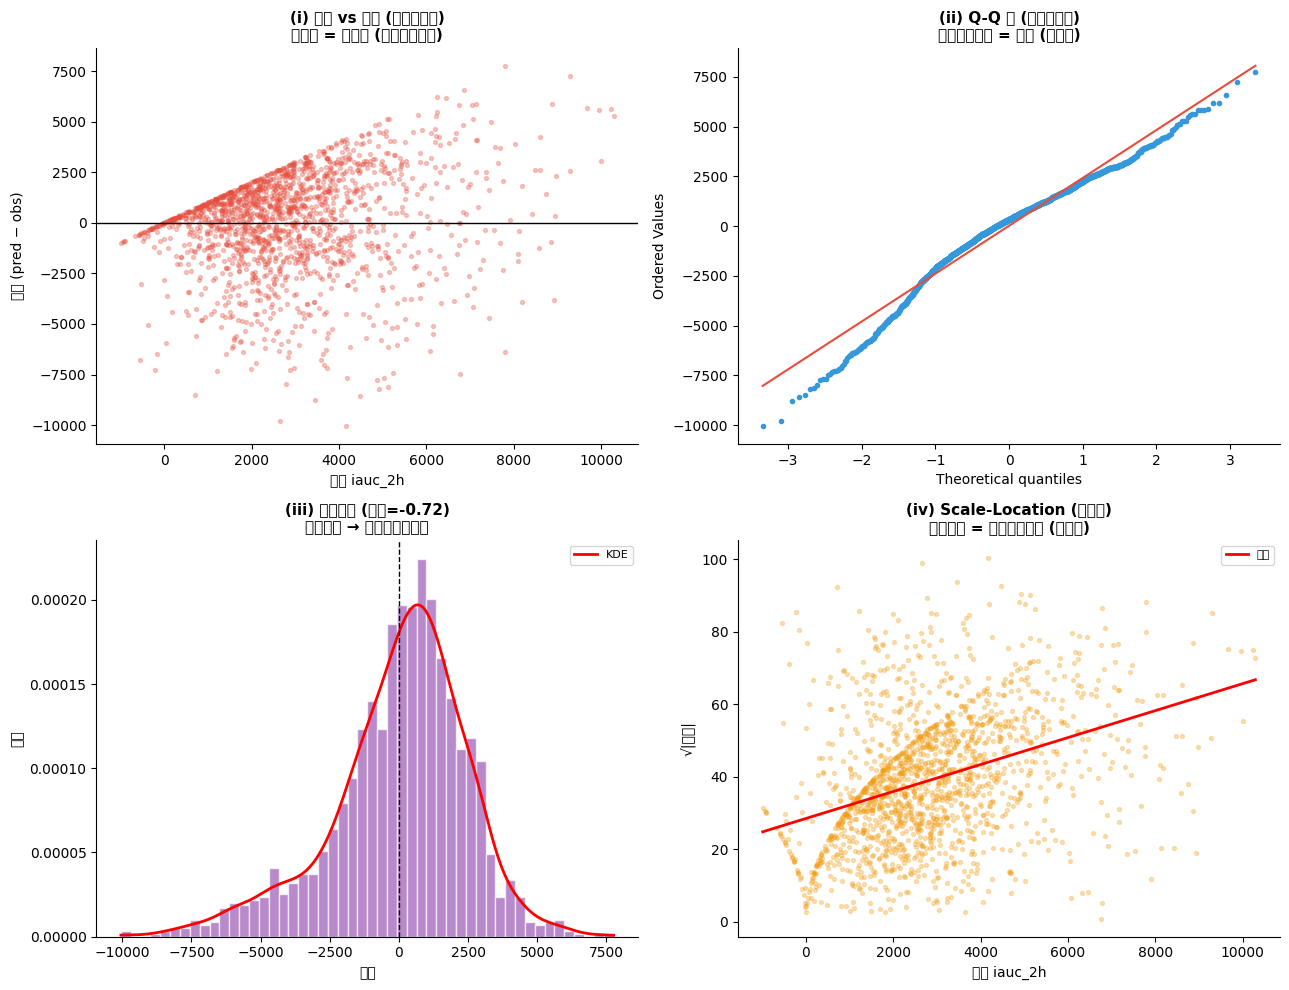

In [26]:

# ============================================================================
# ⑨ 回归校准 + 残差诊断 — 对照教程 11
# ============================================================================
print("\n" + "=" * 70)
print("⑨ 回归校准 + 残差诊断  (对照教程 11, 替代校准/DCA)")
print("=" * 70)
print("  ▶ 回归无阈值 → 无校准曲线/DCA; 改用: 观测vs预测 + 残差诊断 (QQ/同方差)")

# 用最佳模型的 GroupKFold OOF 预测做校准 + 残差
best_oof = oof_preds[best_name]
y_t = best_oof["y_true"].values
y_p = best_oof["y_pred"].values
resid = y_p - y_t
slope, intercept = fit_linear_calibrator(y_t, y_p)
# 预测 SD / 观测 SD (压缩检查: <1 表示预测被压缩)
sd_ratio = np.std(y_p) / np.std(y_t) if np.std(y_t) > 0 else np.nan

print(f"\n  ▶ 回归校准 (最佳模型 {best_name}, GroupKFold OOF):")
print(f"     观测 = {intercept:+.1f} + {slope:.3f} × 预测  (理想 slope=1, intercept=0)")
print(f"     预测SD/观测SD = {sd_ratio:.3f}  (<1 = 预测被压缩, 回归到均值)")
print(f"  ▶ 残差统计: 均值={resid.mean():+.1f}  std={resid.std():.1f}  "
      f"偏度={stats.skew(resid):.2f}")

with open(os.path.join(RESULTS_DIR, "22_calibration_summary.txt"), 'w', encoding='utf-8') as f:
    f.write("回归校准 + 残差诊断汇总 (替代分类的校准曲线/DCA)\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"最佳模型: {best_name} (GroupKFold R²={model_results[best_name]['GKF']['R2']:.3f})\n")
    f.write(f"评估方式: GroupKFold out-of-fold 预测 (n={len(y_t)})\n\n")
    f.write(f"[回归校准] observed = intercept + slope × predicted\n")
    f.write(f"  slope = {slope:.4f}  (理想 1.0; <1 = 预测被压缩)\n")
    f.write(f"  intercept = {intercept:.4f}  (理想 0.0)\n")
    f.write(f"  预测SD/观测SD = {sd_ratio:.4f}  (压缩指标)\n\n")
    f.write(f"[残差诊断] residual = predicted - observed\n")
    f.write(f"  均值 = {resid.mean():.4f}  (理想 0 = 无系统偏差)\n")
    f.write(f"  标准差 = {resid.std():.4f}\n")
    f.write(f"  偏度 = {stats.skew(resid):.4f}\n")
    f.write(f"  峰度 = {stats.kurtosis(resid):.4f}\n")
    f.write(f"  Shapiro-Wilk 正态性 p = {stats.shapiro(resid[:5000] if len(resid)>5000 else resid)[1]:.4e}\n")
print(f"  📄 22_calibration_summary.txt → 校准+残差汇总已保存")

# 9a. 回归校准图 (观测 vs 预测)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_p, y_t, s=8, alpha=0.3, color='#3498db')
lims = [min(y_p.min(), y_t.min()), max(y_p.max(), y_t.max())]
ax.plot(lims, lims, 'k--', lw=1, label='理想 y=x')
x_line = np.linspace(lims[0], lims[1], 100)
ax.plot(x_line, intercept + slope * x_line, 'r-', lw=2,
        label=f'拟合: y={intercept:+.0f}+{slope:.2f}x')
ax.set_xlabel('预测 iauc_2h'); ax.set_ylabel('观测 iauc_2h')
ax.set_title(f'⑨ 回归校准 ({best_name})\nslope={slope:.3f} (理想1), SD比={sd_ratio:.3f} (压缩)',
             fontsize=12, fontweight='bold')
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "22_regression_calibration.png"), dpi=150, bbox_inches='tight')
# plt.close()
print(f"  [图] 22_regression_calibration.png → 回归校准图已保存")

# 9b. 残差诊断 4-panel
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
# (i) 残差 vs 预测 (同方差检查)
axes[0, 0].scatter(y_p, resid, s=8, alpha=0.3, color='#e74c3c')
axes[0, 0].axhline(0, color='k', lw=1)
axes[0, 0].set_xlabel('预测 iauc_2h'); axes[0, 0].set_ylabel('残差 (pred − obs)')
axes[0, 0].set_title(f'(i) 残差 vs 预测 (同方差检查)\n漏斗形 = 异方差 (高值预测不准)',
                     fontsize=11, fontweight='bold')
axes[0, 0].spines['top'].set_visible(False); axes[0, 0].spines['right'].set_visible(False)
# (ii) Q-Q plot
stats.probplot(resid, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title(f'(ii) Q-Q 图 (残差正态性)\n两端偏离直线 = 重尾 (非正态)',
                     fontsize=11, fontweight='bold')
axes[0, 1].spines['top'].set_visible(False); axes[0, 1].spines['right'].set_visible(False)
axes[0, 1].get_lines()[0].set_color('#3498db'); axes[0, 1].get_lines()[0].set_markersize(3)
axes[0, 1].get_lines()[1].set_color('#e74c3c')
# (iii) 残差直方图 + KDE
axes[1, 0].hist(resid, bins=50, color='#9b59b6', alpha=0.7, edgecolor='white', density=True)
x_kde = np.linspace(resid.min(), resid.max(), 200)
kde = stats.gaussian_kde(resid)
axes[1, 0].plot(x_kde, kde(x_kde), 'r-', lw=2, label='KDE')
axes[1, 0].axvline(0, color='k', ls='--', lw=1)
axes[1, 0].set_xlabel('残差'); axes[1, 0].set_ylabel('密度')
axes[1, 0].set_title(f'(iii) 残差分布 (偏度={stats.skew(resid):.2f})\n偏离正态 → 置信区间不可靠',
                     fontsize=11, fontweight='bold')
axes[1, 0].legend(fontsize=8); axes[1, 0].spines['top'].set_visible(False); axes[1, 0].spines['right'].set_visible(False)
# (iv) scale-location
sq_resid = np.sqrt(np.abs(resid))
axes[1, 1].scatter(y_p, sq_resid, s=8, alpha=0.3, color='#f39c12')
# 趋势线
z = np.polyfit(y_p, sq_resid, 1)
x_sl = np.linspace(y_p.min(), y_p.max(), 100)
axes[1, 1].plot(x_sl, np.polyval(z, x_sl), 'r-', lw=2, label='趋势')
axes[1, 1].set_xlabel('预测 iauc_2h'); axes[1, 1].set_ylabel('√|残差|')
axes[1, 1].set_title(f'(iv) Scale-Location (同方差)\n趋势上升 = 高值方差更大 (异方差)',
                     fontsize=11, fontweight='bold')
axes[1, 1].legend(fontsize=8); axes[1, 1].spines['top'].set_visible(False); axes[1, 1].spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "22_residual_diagnostics.png"), dpi=150, bbox_inches='tight')
# plt.close()
print(f"  [图] 22_residual_diagnostics.png → 4-panel 残差诊断已保存")


⑩ SHAP 可解释性分析  (对照教程 12)
  ▶ 同 API (TreeExplainer), 但 SHAP 值 = 目标单位 (mg/dL·min), 非 log-odds
  ▶ 解释模型: HGB (树模型中 GroupKFold R² 最高)
  ▶ SHAP 值形状: (352, 36)  (子样本 352 餐, 变换后 36 特征)
  ▶ SHAP 值单位 = mg/dL·min (目标单位, 非 log-odds)
  ▶ SHAP Top-10 特征 (目标单位贡献):
     eff_carbs                    |SHAP|=714.7
     Fasting GLU - PDL (Lab)      |SHAP|=488.5
     prev_meal_gap_min            |SHAP|=366.1
     A1c PDL (Lab)                |SHAP|=356.7
     baseline_glucose             |SHAP|=330.1
     pre_glucose_slope_60         |SHAP|=253.5
     Cholesterol                  |SHAP|=244.5
     eff_protein                  |SHAP|=218.2
     pre_glucose_sd_30            |SHAP|=158.8
     eff_fiber                    |SHAP|=147.6
  [图] 22_shap_beeswarm.png → 蜂群图已保存
  [图] 22_shap_importance.png → 重要性柱状图已保存
  [图] 22_shap_waterfall.png → 瀑布图已保存
  [图] 22_shap_dependence.png → 依赖图已保存
  📄 22_shap_importance.csv → SHAP 重要性已保存


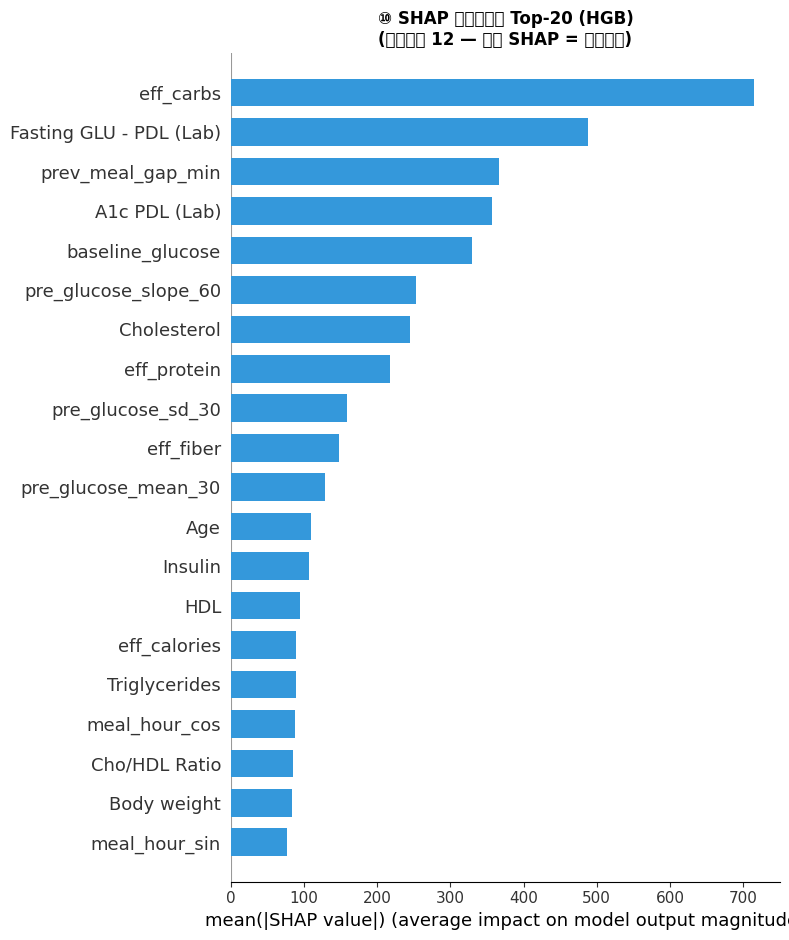

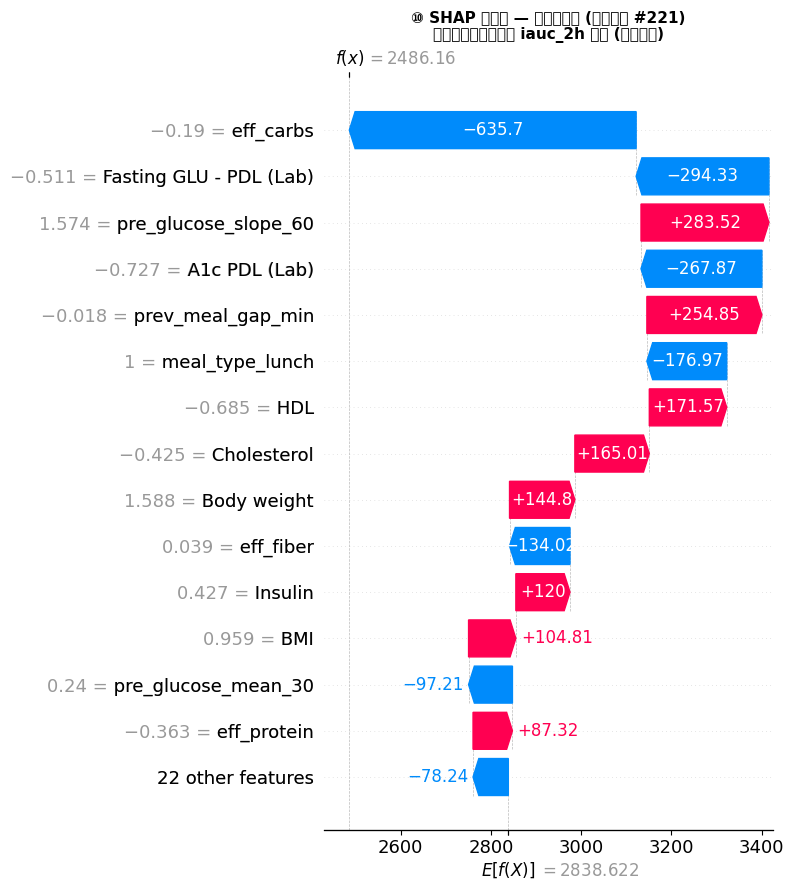

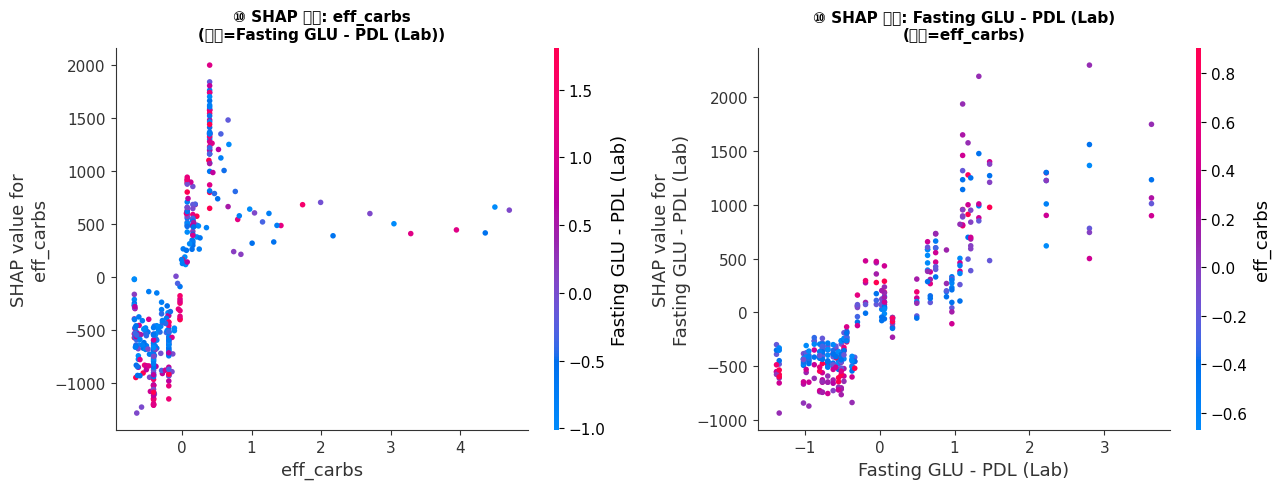

In [27]:

# ============================================================================
# ⑩ SHAP 可解释性 — 对照教程 12
# ============================================================================
print("\n" + "=" * 70)
print("⑩ SHAP 可解释性分析  (对照教程 12)")
print("=" * 70)
print("  ▶ 同 API (TreeExplainer), 但 SHAP 值 = 目标单位 (mg/dL·min), 非 log-odds")

# 用最佳树模型 (在树模型中按 GroupKFold R² 选)
tree_models = ["RandomForest", "HGB", "XGBoost", "LightGBM", "DecisionTree"]
tree_models = [n for n in tree_models if n in model_results]
shap_model_name = max(tree_models, key=lambda k: model_results[k]["GKF"]["R2"])
print(f"  ▶ 解释模型: {shap_model_name} (树模型中 GroupKFold R² 最高)")

# 在受试者内时间划分的训练集上训练, 测试集上算 SHAP
tmp_df, data_sorted, tr_idx, te_idx = split_temporal_holdout(df, PRIMARY_TARGET, M3, models[shap_model_name])
features = M3["numeric"] + M3["categorical"]
pipe = make_pipeline(models[shap_model_name], M3["numeric"], M3["categorical"])
pipe.fit(data_sorted.iloc[tr_idx][features], data_sorted.iloc[tr_idx][PRIMARY_TARGET].values)

# 取预处理后的测试矩阵给 SHAP
pre = pipe.named_steps["preprocess"]
X_test_trans = pre.transform(data_sorted.iloc[te_idx][features])
# 获取变换后特征名
feat_names_trans = []
for name_, trans_, cols_ in pre.transformers_:
    if trans_ == "drop" or cols_ is None:
        continue
    if name_ == "num":
        feat_names_trans += list(cols_)
    elif name_ == "cat":
        try:
            feat_names_trans += list(trans_.named_steps["onehot"].get_feature_names_out(cols_))
        except Exception:
            feat_names_trans += list(cols_)

# 子样本 for beeswarm
rng = np.random.RandomState(RANDOM_STATE)
n_shap = min(SHAP_SAMPLE, X_test_trans.shape[0])
shap_idx = rng.choice(X_test_trans.shape[0], size=n_shap, replace=False)
X_shap = X_test_trans[shap_idx]

explainer = shap.TreeExplainer(pipe.named_steps["model"])
shap_values = explainer.shap_values(X_shap)
sv = np.asarray(shap_values)
if sv.ndim == 3:   # 某些模型返回 (n, feat, 1)
    sv = sv.squeeze(-1)
print(f"  ▶ SHAP 值形状: {sv.shape}  (子样本 {n_shap} 餐, 变换后 {X_shap.shape[1]} 特征)")
print(f"  ▶ SHAP 值单位 = mg/dL·min (目标单位, 非 log-odds)")

# 全局重要性
global_imp = np.abs(sv).mean(axis=0)
imp_order = np.argsort(-global_imp)
feat_arr = np.array(feat_names_trans)
print(f"  ▶ SHAP Top-10 特征 (目标单位贡献):")
for k in imp_order[:10]:
    print(f"     {feat_arr[k]:<28} |SHAP|={global_imp[k]:.1f}")

pd.DataFrame({"feature": feat_arr, "mean_abs_shap": global_imp}).sort_values(
    "mean_abs_shap", ascending=False).to_csv(
    os.path.join(RESULTS_DIR, "22_shap_importance.csv"), index=False)

# 图1: 蜂群图
plt.figure(figsize=(9, 8))
shap.summary_plot(sv, X_shap, feature_names=list(feat_arr), show=False, max_display=20)
plt.title(f'⑩ SHAP Beeswarm Top-20 ({shap_model_name})\nSHAP值=目标单位 mg/dL·min (非log-odds)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "22_shap_beeswarm.png"), dpi=150, bbox_inches='tight')
plt.close()
print(f"  [图] 22_shap_beeswarm.png → 蜂群图已保存")

# 图2: 重要性柱状图
plt.figure(figsize=(9, 7))
shap.summary_plot(sv, X_shap, feature_names=list(feat_arr), plot_type='bar',
                  show=False, max_display=20, color='#3498db')
plt.title(f'⑩ SHAP 全局重要性 Top-20 ({shap_model_name})\n(对照教程 12 — 回归 SHAP = 目标单位)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "22_shap_importance.png"), dpi=150, bbox_inches='tight')
# plt.close()
print(f"  [图] 22_shap_importance.png → 重要性柱状图已保存")

# 图3: 单样本瀑布图 (选一个高响应餐次)
ev = explainer.expected_value
ev = float(ev) if np.size(ev) == 1 else float(ev[0])
sample_idx = int(np.argmax(data_sorted.iloc[te_idx][PRIMARY_TARGET].values[:n_shap]))
plt.figure(figsize=(9, 8))
shap.waterfall_plot(shap.Explanation(values=sv[sample_idx], base_values=ev,
                                     data=X_shap[sample_idx],
                                     feature_names=list(feat_arr)),
                    max_display=15, show=False)
plt.title(f'⑩ SHAP 瀑布图 — 高响应餐次 (测试样本 #{sample_idx})\n'
          f'展示各特征如何推高 iauc_2h 预测 (目标单位)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "22_shap_waterfall.png"), dpi=150, bbox_inches='tight')
# plt.close()
print(f"  [图] 22_shap_waterfall.png → 瀑布图已保存")

# 图4: 依赖图 (Top-2 特征)
top2 = imp_order[:2]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, fi in zip(axes, top2):
    color_feat = imp_order[1] if fi == imp_order[0] else imp_order[0]
    shap.dependence_plot(fi, sv, X_shap, feature_names=list(feat_arr),
                         interaction_index=int(color_feat), ax=ax, show=False)
    ax.set_title(f'⑩ SHAP 依赖: {feat_arr[fi]}\n(颜色={feat_arr[color_feat]})',
                 fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "22_shap_dependence.png"), dpi=150, bbox_inches='tight')
# plt.close()
print(f"  [图] 22_shap_dependence.png → 依赖图已保存")
print(f"  📄 22_shap_importance.csv → SHAP 重要性已保存")

